# 05 — Modelling dan Perkiraan Permintaan
## Ride-Hailing Demand & Operational Analytics

**Sumber:** `output/final/hourly_demand_2024_2026.parquet`
**Prasyarat:** notebook 04 Business Analytics selesai

---

### Apa yang dihasilkan notebook ini

1. **Perkiraan permintaan 1–7 Juni 2026**, untuk setiap zona × provider × jam, dengan tiga angka:

| Angka | Artinya |
|---|---|
| **Batas bawah** | Skenario sepi. Permintaan diperkirakan lebih rendah dari angka ini hanya 1 dari 10 kali |
| **Perkiraan** | Angka paling mungkin, dipakai sebagai dasar perencanaan |
| **Batas atas** | Skenario ramai. Permintaan diperkirakan lebih tinggi dari angka ini hanya 1 dari 10 kali |

   Jadi 8 dari 10 kali, permintaan nyata diperkirakan berada di antara batas bawah dan batas atas.

2. **Tabel perkiraan** untuk seluruh kota per hari, per zona per hari, dan per seri per jam.

3. **Bukti bahwa perkiraan itu dapat dipercaya**: lima model dibandingkan, dipilih dengan data validasi, lalu dinilai sekali pada data uji dengan beberapa ukuran kesalahan.

### Alur

| Tahap | Isi |
|---|---|
| Step 1–4 | Data, seri, grid jam lengkap, fitur |
| Step 5–6 | Membagi periode dan menghitung pembanding sederhana |
| Step 7 | Lima kandidat model dilatih dan dibandingkan pada periode validasi |
| Step 8 | Model terpilih dinilai pada periode uji |
| Step 9 | Batas bawah dan batas atas dikalibrasi dan diuji |
| Step 10 | Perkiraan 1–7 Juni 2026 dan tabelnya |
| Step 11–12 | Menyimpan hasil dan ringkasan |

### Pembagian periode

| Periode | Rentang | Dipakai untuk |
|---|---|---|
| Latih | Februari 2024 – September 2025 | Melatih kandidat model |
| Validasi | Oktober – Desember 2025 | **Memilih** model, pembanding, dan jumlah iterasi; mengkalibrasi batas bawah dan atas |
| Uji | Januari – Mei 2026 | **Menilai** sekali, tidak dipakai untuk memilih apa pun |
| Perkiraan | 1 – 7 Juni 2026 | Hasil akhir, model dilatih ulang pada seluruh data |

### Keputusan jarak perkiraan

Perkiraan dibuat **hingga 7 hari ke depan**. Seluruh fitur hanya memakai data paling baru 168 jam sebelum jam yang diperkirakan, sehingga perkiraan 1–7 Juni hanya memakai data sampai 31 Mei.

### Ukuran keberhasilan

Model berhasil bila pada periode uji kesalahannya lebih kecil dari **pembanding sederhana terbaik**, di seluruh seri dan di setiap kelompok seri, dan batas bawah–atas benar-benar mengapit sekitar 80% kenyataan.

---

# SETUP

In [1]:
# ============================================================
# SETUP
# ============================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import gc
import time
import duckdb
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---------- Lokasi file ----------
PROJECT_ROOT = Path("/Users/auliaaorama/Project/Ride hailing")
SUMBER       = PROJECT_ROOT / "output" / "final" / "hourly_demand_2024_2026.parquet"
FOLDER_MODEL = PROJECT_ROOT / "output" / "model"
FOLDER_MODEL.mkdir(parents=True, exist_ok=True)
FITUR_PATH   = FOLDER_MODEL / "fitur.parquet"
SERI_PATH    = FOLDER_MODEL / "seri_info.parquet"

# ---------- Nama kolom di file sumber ----------
COL = {"jam": "request_hour", "provider": "provider", "zona": "pickup_location_id", "demand": "demand"}

# ---------- Periode ----------
AWAL_DATA       = "2024-01-01 00:00:00"
AKHIR_DATA      = "2026-05-31 23:00:00"
LATIH_MULAI     = "2024-02-01 00:00:00"
VAL_MULAI       = "2025-10-01 00:00:00"
TEST_MULAI      = "2026-01-01 00:00:00"
PERKIRAAN_MULAI = "2026-06-01 00:00:00"
PERKIRAAN_AKHIR = "2026-06-07 23:00:00"

TGL_SEMI = ["2024-03-10", "2025-03-09", "2026-03-08"]   # jam 02:00 dilompati, waktu lokal New York

# ---------- Keputusan ----------
CAKUPAN     = 0.95        # porsi permintaan yang dimodelkan
TOTAL_BA    = 589_055_372
BATAS_POIN  = 1.0         # selisih minimal per 100 perjalanan agar disebut berbeda (penilaian)
BATAS_SETARA = 0.1        # selisih WMAPE di bawah ini: kandidat dianggap setara (pemilihan model)
BATAS_BIAS   = 3.0        # kandidat dengan bias melebihi ±3% tidak boleh dipilih
Q_BAWAH, Q_ATAS = 0.10, 0.90   # batas bawah dan atas: 8 dari 10 kali kenyataan di antaranya

# ---------- DuckDB di memori, dengan batas memori ----------
FOLDER_TMP = FOLDER_MODEL / "tmp"
FOLDER_TMP.mkdir(exist_ok=True)
con = duckdb.connect(config={"memory_limit": "3GB", "temp_directory": str(FOLDER_TMP)})
con.execute("SET TimeZone = 'UTC'")            # nilai waktu dibaca apa adanya
con.execute("SET enable_progress_bar = false")

print("Sumber ada :", SUMBER.exists())
print("DuckDB", duckdb.__version__, "| LightGBM", lgb.__version__)

Sumber ada : True
DuckDB 1.5.5 | LightGBM 4.6.0


In [2]:
# ============================================================
# STYLE GRAFIK
# ============================================================
%config InlineBackend.figure_format = "retina"

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

C = {"primary": "#1F4E79", "secondary": "#E07B39", "accent": "#2E8B74", "muted": "#9AA5B1",
     "alert": "#C0392B", "grid": "#E4E7EB", "text": "#2C3A47", "bg": "#FFFFFF", "band": "#AFC6DD"}

mpl.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": C["bg"], "axes.edgecolor": C["muted"],
    "axes.linewidth": 0.8, "axes.labelcolor": C["text"], "axes.titlesize": 13,
    "axes.titleweight": "semibold", "axes.titlecolor": C["text"], "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 10, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": C["grid"], "grid.linewidth": 0.8, "xtick.color": C["text"], "ytick.color": C["text"],
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.frameon": False, "legend.fontsize": 9.5,
    "lines.linewidth": 2.0, "font.size": 10, "figure.dpi": 110, "savefig.dpi": 200,
    "savefig.bbox": "tight",
})
RIBU = FuncFormatter(lambda v, p: f"{v / 1000:,.0f} rb" if abs(v) >= 1000 else f"{v:,.0f}")


def clean_axes(ax, x_grid=False):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", visible=True)
    ax.grid(axis="x", visible=x_grid)
    return ax


def titled(ax, title, sub=None):
    ax.set_title(title, loc="left", pad=30 if sub else 14)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=9.5, color=C["muted"], va="bottom")
    return ax


def label_ujung(ax, x, nilai_nama_warna, fmt="{:.1f}", jarak_rel=0.06):
    # Label di ujung garis, digeser bila berdekatan agar tidak bertumpuk
    lo, hi = ax.get_ylim()
    jarak = (hi - lo) * jarak_rel
    posisi = []
    for v, n, w in sorted(nilai_nama_warna):
        yt = v if not posisi else max(v, posisi[-1] + jarak)
        posisi.append(yt)
        ax.annotate(f" {n} {fmt.format(v)}", xy=(x, yt), va="center", fontsize=9.5,
                    color=w, fontweight="semibold", annotation_clip=False)

print("Style grafik siap.")

Style grafik siap.


In [3]:
# ============================================================
# UKURAN KESALAHAN
# ============================================================
def ukur(y, p, p_pekan_lalu=None):
    '''Beberapa ukuran kesalahan sekaligus, karena tiap ukuran menjawab pertanyaan berbeda.'''
    y, p = np.asarray(y, dtype=float), np.asarray(p, dtype=float)
    hasil = {
        "WMAPE": np.abs(y - p).sum() / y.sum() * 100,
        "MAE": np.abs(y - p).mean(),
        "RMSE": np.sqrt(((y - p) ** 2).mean()),
        "Bias %": (p.sum() / y.sum() - 1) * 100,
    }
    if p_pekan_lalu is not None:
        hasil["Rasio MAE"] = np.abs(y - p).mean() / np.abs(y - np.asarray(p_pekan_lalu, dtype=float)).mean()
    return hasil


def tabel_ukur(df, tebakan, kolom_pekan_lalu="tebak_pekan_lalu"):
    '''Satu baris per cara menebak, satu kolom per ukuran.'''
    return pd.DataFrame({nama: ukur(df["demand"], df[k], df[kolom_pekan_lalu])
                         for k, nama in tebakan.items()}).T


def wmape_per(df, tebakan, by):
    '''Kesalahan per 100 perjalanan, per kelompok.'''
    return df.groupby(by, observed=True).apply(
        lambda g: pd.Series({nama: np.abs(g["demand"] - g[k]).sum() / g["demand"].sum() * 100
                             for k, nama in tebakan.items()}))


FORMAT_UKUR = {"WMAPE": "{:.1f}", "MAE": "{:.2f}", "RMSE": "{:.2f}", "Bias %": "{:+.1f}%", "Rasio MAE": "{:.3f}"}
print("Fungsi ukuran siap.")

Fungsi ukuran siap.


> **Arti setiap ukuran kesalahan**

| Ukuran | Artinya | Lebih baik bila |
|---|---|---|
| **WMAPE** | Berapa perjalanan yang meleset dari setiap 100 perjalanan | Lebih kecil |
| **MAE** | Rata-rata selisih tebakan per seri per jam, dalam jumlah perjalanan | Lebih kecil |
| **RMSE** | Seperti MAE, tetapi kesalahan besar dihukum lebih berat — menunjukkan ada tidaknya meleset jauh | Lebih kecil |
| **Bias %** | Total tebakan dibanding total kenyataan. Positif berarti terlalu tinggi, negatif terlalu rendah | Mendekati 0 |
| **Rasio MAE** | MAE dibagi MAE angka pekan lalu. Di bawah 1 berarti lebih baik dari sekadar meniru pekan lalu | Lebih kecil dari 1 |

Untuk batas bawah dan atas dipakai dua ukuran lagi:

| Ukuran | Artinya | Yang diharapkan |
|---|---|---|
| **Cakupan** | Berapa persen kenyataan jatuh di antara batas bawah dan batas atas | Sekitar 80% |
| **Lebar rata-rata** | Rata-rata jarak batas atas dan batas bawah, dibanding perkiraan | Sesempit mungkin, asalkan cakupan tercapai |

WMAPE dipakai sebagai ukuran utama karena langsung terbaca sebagai persen perjalanan yang meleset. Ukuran lain dipakai untuk memastikan model tidak unggul di satu ukuran tetapi buruk di ukuran lain — misalnya WMAPE kecil tetapi selalu terlalu tinggi.

---

# STEP 1 — Pemeriksaan File Sumber

**Tujuan:** memastikan file lokal berisi data yang sama dengan yang dianalisis di Business Analytics.

**Cara interpretasi:** total perjalanan harus sama persis dengan 589.055.372. Bila nama kolom berbeda, sesuaikan `COL` di cell setup.

In [4]:
display(con.execute(f"DESCRIBE SELECT * FROM read_parquet('{SUMBER}')").df()[["column_name", "column_type"]])

cek = con.execute(f'''
    SELECT COUNT(*) AS baris, SUM({COL["demand"]}) AS total,
           MIN({COL["jam"]}) AS awal, MAX({COL["jam"]}) AS akhir,
           COUNT(DISTINCT {COL["zona"]}) AS n_zona, COUNT(DISTINCT {COL["provider"]}) AS n_provider
    FROM read_parquet('{SUMBER}')
''').df().iloc[0]
print(f"Baris            : {cek['baris']:,}")
print(f"Total perjalanan : {cek['total']:,.0f}")
print(f"Periode          : {cek['awal']} sampai {cek['akhir']}")
print(f"Zona / provider  : {cek['n_zona']} / {cek['n_provider']}")
print(f"\nSama dengan Business Analytics : {'YA' if int(cek['total']) == TOTAL_BA else 'TIDAK — periksa file sumber'}")

,column_name,column_type
0,request_hour,TIMESTAMP
1,provider_code,VARCHAR
2,provider,VARCHAR
3,pickup_location_id,INTEGER
4,demand,DOUBLE


Baris            : 10,446,585
Total perjalanan : 589,055,372
Periode          : 2024-01-01 00:00:00 sampai 2026-05-31 23:00:00
Zona / provider  : 263 / 2

Sama dengan Business Analytics : YA


---

# STEP 2 — Seri yang Dimodelkan

**Tujuan:** menentukan seri zona × provider yang dimodelkan dan kelompoknya.

**Kenapa diperlukan:** seri yang menampung 95% permintaan dimodelkan. Seri sisanya sangat sepi dan hampir semua jam kosong, sehingga diperkirakan dengan rata-rata 4 pekan.

**Mencegah kebocoran informasi:** cakupan, kelompok seri, dan kelompok jam zona dihitung hanya dari data sebelum periode uji.

In [5]:
con.execute(f'''
CREATE OR REPLACE TABLE demand AS
SELECT CAST({COL["jam"]} AS TIMESTAMP) AS jam, CAST({COL["provider"]} AS VARCHAR) AS provider,
       CAST({COL["zona"]} AS INTEGER) AS zona, SUM({COL["demand"]})::DOUBLE AS demand
FROM read_parquet('{SUMBER}')
GROUP BY 1, 2, 3
''')

con.execute(f'''
CREATE OR REPLACE TABLE seri AS
WITH t AS (
    SELECT provider, zona, SUM(demand) AS total
    FROM demand WHERE jam < TIMESTAMP '{TEST_MULAI}' GROUP BY 1, 2
),
r AS (
    SELECT *, SUM(total) OVER (ORDER BY total DESC ROWS UNBOUNDED PRECEDING) / SUM(total) OVER () AS kumulatif,
           total / SUM(total) OVER () AS porsi,
           NTILE(4) OVER (ORDER BY total DESC) AS kelompok_seri
    FROM t
)
SELECT provider, zona, total, porsi, kelompok_seri, (kumulatif - porsi) < {CAKUPAN} AS dimodelkan FROM r
''')

con.execute(f'''
CREATE OR REPLACE TABLE zona_info AS
WITH p AS (SELECT zona, hour(jam) AS jam_hari, SUM(demand) AS d
           FROM demand WHERE jam < TIMESTAMP '{TEST_MULAI}' GROUP BY 1, 2),
pk AS (SELECT zona, arg_max(jam_hari, d) AS jam_puncak FROM p GROUP BY zona)
SELECT zona, jam_puncak,
       CASE WHEN jam_puncak BETWEEN 6 AND 11 THEN 'pagi' WHEN jam_puncak BETWEEN 12 AND 16 THEN 'siang'
            WHEN jam_puncak BETWEEN 17 AND 19 THEN 'sore' ELSE 'malam' END AS kelompok_jam
FROM pk
''')

try:
    lookup = pd.read_csv("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv") \
               .rename(columns={"LocationID": "zona", "Borough": "borough", "Zone": "nama_zona"})
except Exception as e:
    print("Lookup zona tidak dapat diunduh:", type(e).__name__)
    lookup = pd.DataFrame({"zona": con.execute("SELECT DISTINCT zona FROM demand").df()["zona"],
                           "borough": "Unknown", "nama_zona": "—"})
con.register("lookup_df", lookup[["zona", "borough", "nama_zona"]])
con.execute("CREATE OR REPLACE TABLE lookup AS SELECT * FROM lookup_df")

seri_info = con.execute('''
    SELECT s.provider, s.zona, s.total, s.porsi, s.kelompok_seri, s.dimodelkan, z.kelompok_jam,
           COALESCE(k.borough, 'Unknown') AS borough, COALESCE(k.nama_zona, '—') AS nama_zona
    FROM seri s LEFT JOIN zona_info z USING (zona) LEFT JOIN lookup k USING (zona)
''').df()
seri_info.to_parquet(SERI_PATH, index=False)

display(seri_info.groupby("dimodelkan").agg(n_seri=("zona", "size"), porsi=("porsi", "sum"))
        .sort_index(ascending=False).style.format({"porsi": "{:.1%}"}))
display(seri_info.groupby("kelompok_seri").agg(n_seri=("zona", "size"), porsi=("porsi", "sum"),
                                                dimodelkan=("dimodelkan", "sum"))
        .style.format({"porsi": "{:.1%}"}))

,n_seri,porsi
dimodelkan,,
True,359,95.1%
False,165,4.9%


,n_seri,porsi,dimodelkan
kelompok_seri,,,
1,131,61.6%,131
2,131,24.4%,131
3,131,11.1%,97
4,131,2.9%,0


---

# STEP 3 — Grid Jam Lengkap

**Tujuan:** satu baris untuk setiap seri pada setiap jam, termasuk jam tanpa perjalanan dan 7 hari yang akan diperkirakan.

**Aturan waktu:**
- Jam dibuat dari 1 Januari 2024 sampai 7 Juni 2026
- Jam 02:00 pada tanggal pergantian musim semi tidak dibuat, karena tidak pernah terjadi
- Sampai 31 Mei 2026, jam tanpa perjalanan diisi 0
- 1–7 Juni 2026 dibiarkan kosong, karena itulah yang akan diperkirakan

**Cara interpretasi:** jam kosong seharusnya sekitar 5,8%, dan selisih total perjalanan hanya sebesar yang tercatat di jam 02:00 musim semi.

In [6]:
semi = ", ".join(f"DATE '{t}'" for t in TGL_SEMI)
con.execute(f'''
CREATE OR REPLACE TABLE jam_grid AS
SELECT jam FROM (SELECT UNNEST(generate_series(TIMESTAMP '{AWAL_DATA}', TIMESTAMP '{PERKIRAAN_AKHIR}',
                                               INTERVAL 1 HOUR)) AS jam)
WHERE NOT (hour(jam) = 2 AND CAST(jam AS DATE) IN ({semi}))
''')
con.execute(f'''
CREATE OR REPLACE TABLE grid AS
SELECT s.provider, s.zona, g.jam,
       CASE WHEN g.jam <= TIMESTAMP '{AKHIR_DATA}' THEN COALESCE(d.demand, 0) END AS demand
FROM seri s CROSS JOIN jam_grid g
LEFT JOIN demand d ON d.provider = s.provider AND d.zona = s.zona AND d.jam = g.jam
''')

g = con.execute(f'''
    SELECT COUNT(*) FILTER (WHERE jam <= TIMESTAMP '{AKHIR_DATA}') AS baris_data,
           COUNT(*) FILTER (WHERE jam >  TIMESTAMP '{AKHIR_DATA}') AS baris_perkiraan,
           SUM(demand) AS total, COUNT(*) FILTER (WHERE demand = 0) AS kosong
    FROM grid
''').df().iloc[0]
total_sumber = con.execute("SELECT SUM(demand) FROM demand").fetchone()[0]
lompat = con.execute(f"SELECT COALESCE(SUM(demand), 0) FROM demand WHERE hour(jam) = 2 AND CAST(jam AS DATE) IN ({semi})").fetchone()[0]

print(f"Baris data (sampai 31 Mei)    : {g['baris_data']:,.0f}")
print(f"Baris perkiraan (1–7 Juni)    : {g['baris_perkiraan']:,.0f}")
print(f"Jam tanpa perjalanan          : {g['kosong']:,.0f} ({g['kosong'] / g['baris_data'] * 100:.1f}%)")
print(f"Total perjalanan sumber / grid: {total_sumber:,.0f} / {g['total']:,.0f}")
print(f"Tercatat di jam 02:00 musim semi : {lompat:,.0f}")
print(f"Selisih dijelaskan seluruhnya : {'YA' if abs(total_sumber - g['total'] - lompat) < 0.5 else 'TIDAK — periksa grid'}")

Baris data (sampai 31 Mei)    : 11,090,460
Baris perkiraan (1–7 Juni)    : 88,032
Jam tanpa perjalanan          : 643,885 (5.8%)
Total perjalanan sumber / grid: 589,055,372 / 589,055,361
Tercatat di jam 02:00 musim semi : 11
Selisih dijelaskan seluruhnya : YA


---

# STEP 4 — Fitur

**Aturan utama:** fitur yang memakai permintaan masa lalu hanya boleh memakai data **paling baru 168 jam** sebelum jam yang diperkirakan.

| Kelompok | Fitur |
|---|---|
| Pekan sebelumnya | Permintaan jam yang sama 1, 2, 3, dan 4 pekan lalu |
| Perataan | Rata-rata jam yang sama 4 pekan terakhir |
| Tingkat terbaru | Rata-rata 1 hari, 1 pekan, dan 4 pekan yang berakhir 168 jam lalu |
| Tahun lalu (fitur tren) | Jam yang sama 52 pekan lalu, rata-rata 4 pekan setahun lalu, dan rasio tingkat terbaru terhadap setahun lalu |
| Kalender | Jam, hari, bulan, libur nasional, malam Jumat–Sabtu |
| Zona | Zona, provider, borough, kelompok jam zona, kelompok seri |

**Fitur yang sengaja tidak dipakai: hitungan hari (`indeks_hari`).** Pada percobaan sebelumnya, fitur ini membuat model menebak 7,2% terlalu tinggi dan meleset 19,9 dari 100, lebih buruk dari rata-rata 4 pekan (18,5). Model pohon tidak dapat memperpanjang tren: untuk tanggal di luar data latih ia memakai tingkat periode terakhir yang dilihatnya, yaitu Oktober–Desember yang merupakan musim paling ramai, lalu menerapkannya ke Januari–Mei yang lebih sepi. Tingkat terbaru sudah ditangkap oleh fitur rata-rata 1 hari, 1 pekan, dan 4 pekan.

In [7]:
from pandas.tseries.holiday import USFederalHolidayCalendar
libur = USFederalHolidayCalendar().holidays(start="2024-01-01", end="2026-12-31")
con.register("libur_df", pd.DataFrame({"tanggal": libur.date}))
con.execute("CREATE OR REPLACE TABLE libur AS SELECT CAST(tanggal AS DATE) AS tanggal FROM libur_df")

t0 = time.time()
con.execute('''
CREATE OR REPLACE TABLE fitur AS
SELECT
    g.provider, g.zona, g.jam, g.demand,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 168 HOUR PRECEDING AND INTERVAL 168 HOUR PRECEDING)   AS lag_1pekan,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 336 HOUR PRECEDING AND INTERVAL 336 HOUR PRECEDING)   AS lag_2pekan,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 504 HOUR PRECEDING AND INTERVAL 504 HOUR PRECEDING)   AS lag_3pekan,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 672 HOUR PRECEDING AND INTERVAL 672 HOUR PRECEDING)   AS lag_4pekan,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 8736 HOUR PRECEDING AND INTERVAL 8736 HOUR PRECEDING) AS lag_52pekan,
    AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL 191 HOUR PRECEDING AND INTERVAL 168 HOUR PRECEDING)   AS rata_1hari,
    AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL 335 HOUR PRECEDING AND INTERVAL 168 HOUR PRECEDING)   AS rata_1pekan,
    AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL 839 HOUR PRECEDING AND INTERVAL 168 HOUR PRECEDING)   AS rata_4pekan,
    AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL 9575 HOUR PRECEDING AND INTERVAL 8904 HOUR PRECEDING) AS rata_4pekan_tahun_lalu,
    hour(g.jam) AS jam_hari, isodow(g.jam) AS hari, month(g.jam) AS bulan,
    CAST(l.tanggal IS NOT NULL AS INT) AS libur,
    CAST((isodow(g.jam) = 5 AND hour(g.jam) >= 17)
      OR (isodow(g.jam) = 6 AND (hour(g.jam) >= 17 OR hour(g.jam) < 5))
      OR (isodow(g.jam) = 7 AND hour(g.jam) < 5) AS INT) AS malam_akhir_pekan
FROM grid g
LEFT JOIN libur l ON l.tanggal = CAST(g.jam AS DATE)
WINDOW w AS (PARTITION BY g.provider, g.zona ORDER BY g.jam)
''')

# Angka disimpan sebagai FLOAT (4 byte) agar file dan memori separuhnya
ANGKA = ["demand", "lag_1pekan", "lag_2pekan", "lag_3pekan", "lag_4pekan", "lag_52pekan",
         "rata_1hari", "rata_1pekan", "rata_4pekan", "rata_4pekan_tahun_lalu",
         "jam_hari", "hari", "bulan", "libur", "malam_akhir_pekan"]
angka = ", ".join(f"CAST(f.{k} AS FLOAT) AS {k}" for k in ANGKA)
con.register("seri_info_tbl", seri_info)
con.execute(f'''
COPY (
    SELECT f.provider, f.zona, f.jam, s.kelompok_seri, s.dimodelkan, s.kelompok_jam, s.borough, {angka}
    FROM fitur f JOIN seri_info_tbl s USING (provider, zona)
    WHERE f.jam >= TIMESTAMP '{LATIH_MULAI}'
) TO '{FITUR_PATH}' (FORMAT PARQUET)
''')
print(f"Fitur selesai dalam {time.time() - t0:,.0f} detik, {FITUR_PATH.stat().st_size / 1e6:,.0f} MB")

# Pemeriksaan: lag 1 pekan harus sama dengan permintaan 168 jam lalu
cek = con.execute(f'''
    SELECT AVG(CAST(a.lag_1pekan = b.demand AS INT)) * 100 AS cocok, COUNT(*) AS n
    FROM fitur a JOIN fitur b ON b.provider = a.provider AND b.zona = a.zona AND b.jam = a.jam - INTERVAL 168 HOUR
    WHERE a.jam >= TIMESTAMP '{TEST_MULAI}' AND a.jam <= TIMESTAMP '{AKHIR_DATA}'
''').df().iloc[0]
depan = con.execute(f'''
    SELECT COUNT(*) AS baris, AVG(CAST(lag_1pekan IS NOT NULL AS INT)) * 100 AS ada_lag
    FROM fitur WHERE jam >= TIMESTAMP '{PERKIRAAN_MULAI}'
''').df().iloc[0]
print(f"Lag 1 pekan = permintaan 168 jam lalu : {cek['cocok']:.0f}% dari {cek['n']:,.0f} baris uji")
print(f"Baris 1–7 Juni yang punya lag 1 pekan : {depan['ada_lag']:.0f}% dari {depan['baris']:,.0f}")

con.execute("DROP TABLE grid"); con.execute("DROP TABLE fitur"); gc.collect()

Fitur selesai dalam 13 detik, 216 MB
Lag 1 pekan = permintaan 168 jam lalu : 100% dari 1,897,928 baris uji
Baris 1–7 Juni yang punya lag 1 pekan : 100% dari 88,032


10

---

# STEP 5 — Membagi Periode

**Tujuan:** membaca fitur dan membaginya menjadi latih, validasi, uji, dan perkiraan.

**Cara membaca data:** setiap periode dibaca langsung dari `fitur.parquet`, hanya baris yang diperlukan, agar memori tidak habis. Seri di luar cakupan dibaca terpisah.

**Cara interpretasi:** porsi jam kosong di setiap periode seharusnya mirip.

In [8]:
KAT = ["zona", "provider", "borough", "kelompok_jam", "kelompok_seri"]
KAT_NILAI = {"provider": sorted(seri_info["provider"].unique()), "borough": sorted(seri_info["borough"].unique()),
             "kelompok_jam": ["pagi", "siang", "sore", "malam"], "kelompok_seri": [1, 2, 3, 4],
             "zona": sorted(seri_info["zona"].unique())}


def baca(dimodelkan, dari=None, sampai=None):
    saring = [("dimodelkan", "==", dimodelkan)]
    if dari:
        saring.append(("jam", ">=", pd.Timestamp(dari)))
    if sampai:
        saring.append(("jam", "<", pd.Timestamp(sampai)))
    df = pd.read_parquet(FITUR_PATH, filters=saring)
    lag4 = df[["lag_1pekan", "lag_2pekan", "lag_3pekan", "lag_4pekan"]]
    df["rata_jam_sama_4pekan"] = lag4.mean(axis=1).astype("float32")
    df["rasio_tren"] = (df["rata_4pekan"] / df["rata_4pekan_tahun_lalu"]) \
        .replace([np.inf, -np.inf], np.nan).astype("float32")
    for k in KAT:   # kategori sama di semua periode, agar model menerima data yang seragam
        df[k] = pd.Categorical(df[k], categories=KAT_NILAI[k])
    df["tebak_pekan_lalu"] = df["lag_1pekan"].fillna(0)
    df["tebak_rata_4pekan"] = df["rata_jam_sama_4pekan"].fillna(df["tebak_pekan_lalu"])
    return df.drop(columns=["dimodelkan"]).reset_index(drop=True)


t0 = time.time()
latih = baca(True, sampai=VAL_MULAI)
val   = baca(True, VAL_MULAI, TEST_MULAI)
uji   = baca(True, TEST_MULAI, PERKIRAAN_MULAI)
depan = baca(True, PERKIRAAN_MULAI)
luar_val, luar_uji, luar_depan = (baca(False, VAL_MULAI, TEST_MULAI), baca(False, TEST_MULAI, PERKIRAAN_MULAI),
                                  baca(False, PERKIRAAN_MULAI))
gc.collect()

ringkas = pd.DataFrame({
    "dari":   [d["jam"].min() for d in (latih, val, uji, depan)],
    "sampai": [d["jam"].max() for d in (latih, val, uji, depan)],
    "baris":  [len(d) for d in (latih, val, uji, depan)],
    "perjalanan": [d["demand"].sum() for d in (latih, val, uji)] + [np.nan],
    "jam_kosong": [(d["demand"] == 0).mean() * 100 for d in (latih, val, uji)] + [np.nan],
}, index=["Latih", "Validasi", "Uji", "Perkiraan 1–7 Juni"])
print(f"Dibaca dalam {time.time() - t0:.1f} detik | memori "
      f"{sum(d.memory_usage().sum() for d in (latih, val, uji, depan)) / 1e9:.2f} GB")
print(f"Seri dimodelkan: {latih.groupby(['provider', 'zona'], observed=True).ngroups} | "
      f"di luar cakupan: {luar_uji.groupby(['provider', 'zona'], observed=True).ngroups}\n")
ringkas.style.format({"baris": "{:,.0f}", "perjalanan": "{:,.0f}", "jam_kosong": "{:.1f}%"}, na_rep="—")

Dibaca dalam 2.3 detik | memori 0.67 GB
Seri dimodelkan: 359 | di luar cakupan: 165



,dari,sampai,baris,perjalanan,jam_kosong
Latih,2024-02-01 00:00:00,2025-09-30 23:00:00,"5,237,810","379,588,352",0.1%
Validasi,2025-10-01 00:00:00,2025-12-31 23:00:00,"792,672","60,896,836",0.1%
Uji,2026-01-01 00:00:00,2026-05-31 23:00:00,"1,300,657","100,172,528",0.1%
Perkiraan 1–7 Juni,2026-06-01 00:00:00,2026-06-07 23:00:00,"60,312",—,—


---

# STEP 5B — Autokorelasi: Lag Mana yang Paling Berguna?

**Tujuan:** membuktikan dari data, bukan dari anggapan, jarak waktu mana yang paling mirip dengan jam yang diperkirakan.

**Dua ukuran:**

| Ukuran | Pertanyaan yang dijawab |
|---|---|
| **ACF** (autokorelasi) | Seberapa mirip permintaan sekarang dengan permintaan *k* jam sebelumnya? |
| **PACF** (autokorelasi parsial) | Seberapa mirip, **setelah** pengaruh jam-jam di antaranya disingkirkan? Menunjukkan lag yang membawa informasi baru |

Nilai 1 berarti sangat mirip, 0 berarti tidak berhubungan.

**Batasan dari jarak perkiraan:** karena perkiraan dibuat sampai 7 hari ke depan, lag di bawah 168 jam **tidak boleh dipakai**, sekuat apa pun hubungannya — datanya belum tersedia saat perkiraan dibuat. ACF di wilayah itu tetap ditampilkan agar terlihat informasi apa yang dilepas.

**Data:** hanya periode latih, agar tidak mengintip periode validasi dan uji. Diperiksa untuk seluruh kota dan tiga seri wakil, masing-masing seri terbesar dari kelompok zona pagi, sore, dan malam.

**Cara interpretasi:** lag yang ACF dan PACF-nya menonjol di atas 168 jam adalah lag yang layak menjadi fitur.

In [9]:
def acf(x, nlag):
    '''Autokorelasi untuk lag 0 sampai nlag.'''
    x = np.asarray(x, dtype=float); x = x - x.mean(); d = (x * x).sum()
    return np.array([1.0] + [(x[:-k] * x[k:]).sum() / d for k in range(1, nlag + 1)])


def pacf(r, nlag):
    '''Autokorelasi parsial dari ACF, dengan rekursi Durbin–Levinson.'''
    phi = np.zeros((nlag + 1, nlag + 1)); p = np.zeros(nlag + 1); p[0] = 1
    phi[1, 1] = p[1] = r[1]
    for k in range(2, nlag + 1):
        phi[k, k] = (r[k] - (phi[k - 1, 1:k] * r[k - 1:0:-1]).sum()) / \
                    (1 - (phi[k - 1, 1:k] * r[1:k]).sum())
        phi[k, 1:k] = phi[k - 1, 1:k] - phi[k, k] * phi[k - 1, k - 1:0:-1]
        p[k] = phi[k, k]
    return p


LAG_ACF, LAG_PACF = 700, 200
LAG_KUNCI = [1, 2, 24, 48, 72, 167, 168, 169, 336, 504, 672]

# Deret yang diperiksa: seluruh kota dan satu seri terbesar per kelompok jam zona
deret = {"Seluruh kota": latih.groupby("jam")["demand"].sum().sort_index()}
for kj in ["pagi", "sore", "malam"]:
    s = seri_info[seri_info["dimodelkan"] & (seri_info["kelompok_jam"] == kj)].sort_values("total", ascending=False)
    if len(s):
        r = s.iloc[0]
        d = latih[(latih["zona"] == r["zona"]) & (latih["provider"] == r["provider"])].sort_values("jam")
        deret[f"{r['nama_zona']} · {r['provider']} (zona {kj})"] = d["demand"].to_numpy()

ACF_HASIL = {n: acf(np.asarray(v), LAG_ACF) for n, v in deret.items()}
PACF_KOTA = pacf(ACF_HASIL["Seluruh kota"], LAG_PACF)
N_KOTA = len(deret["Seluruh kota"])
BATAS_ACAK = 1.96 / np.sqrt(N_KOTA)

tabel_acf = pd.DataFrame({n: r[LAG_KUNCI] for n, r in ACF_HASIL.items()}, index=LAG_KUNCI)
tabel_acf["PACF seluruh kota"] = PACF_KOTA[[k for k in LAG_KUNCI if k <= LAG_PACF] +
                                          [0] * sum(k > LAG_PACF for k in LAG_KUNCI)]
tabel_acf.loc[[k for k in LAG_KUNCI if k > LAG_PACF], "PACF seluruh kota"] = np.nan
tabel_acf.index = [f"{k} jam" + (f" ({k // 24} hari)" if k % 24 == 0 else "") for k in LAG_KUNCI]
tabel_acf.index.name = "Lag"

print(f"Panjang deret seluruh kota: {N_KOTA:,} jam. Batas tidak berbeda dari acak: ±{BATAS_ACAK:.3f}\n")
display(tabel_acf.style.format("{:.3f}", na_rep="—"))

sah = np.arange(168, LAG_ACF + 1)
top = sah[np.argsort(ACF_HASIL["Seluruh kota"][sah])[::-1][:5]]
print("Lag sah (≥ 168 jam) dengan ACF seluruh kota tertinggi:", ", ".join(f"{k} jam" for k in sorted(top)))
top_p = np.argsort(np.abs(PACF_KOTA[1:]))[::-1][:8] + 1
print("Lag dengan PACF seluruh kota terbesar (0–200 jam):", ", ".join(f"{k}" for k in sorted(top_p)))

Panjang deret seluruh kota: 14,590 jam. Batas tidak berbeda dari acak: ±0.016



,Seluruh kota,Central Harlem North · Uber (zona pagi),Crown Heights North · Uber (zona sore),LaGuardia Airport · Uber (zona malam),PACF seluruh kota
Lag,,,,,
1 jam,0.913,0.838,0.904,0.858,0.913
2 jam,0.710,0.563,0.732,0.706,-0.742
24 jam (1 hari),0.815,0.784,0.764,0.793,-0.274
48 jam (2 hari),0.623,0.603,0.536,0.742,-0.005
72 jam (3 hari),0.562,0.540,0.459,0.791,-0.056
167 jam,0.856,0.768,0.833,0.791,0.169
168 jam (7 hari),0.930,0.877,0.894,0.873,-0.084
169 jam,0.850,0.760,0.827,0.784,-0.269
336 jam (14 hari),0.906,0.849,0.871,0.851,—


Lag sah (≥ 168 jam) dengan ACF seluruh kota tertinggi: 168 jam, 169 jam, 336 jam, 504 jam, 672 jam
Lag dengan PACF seluruh kota terbesar (0–200 jam): 1, 2, 19, 20, 22, 24, 25, 169


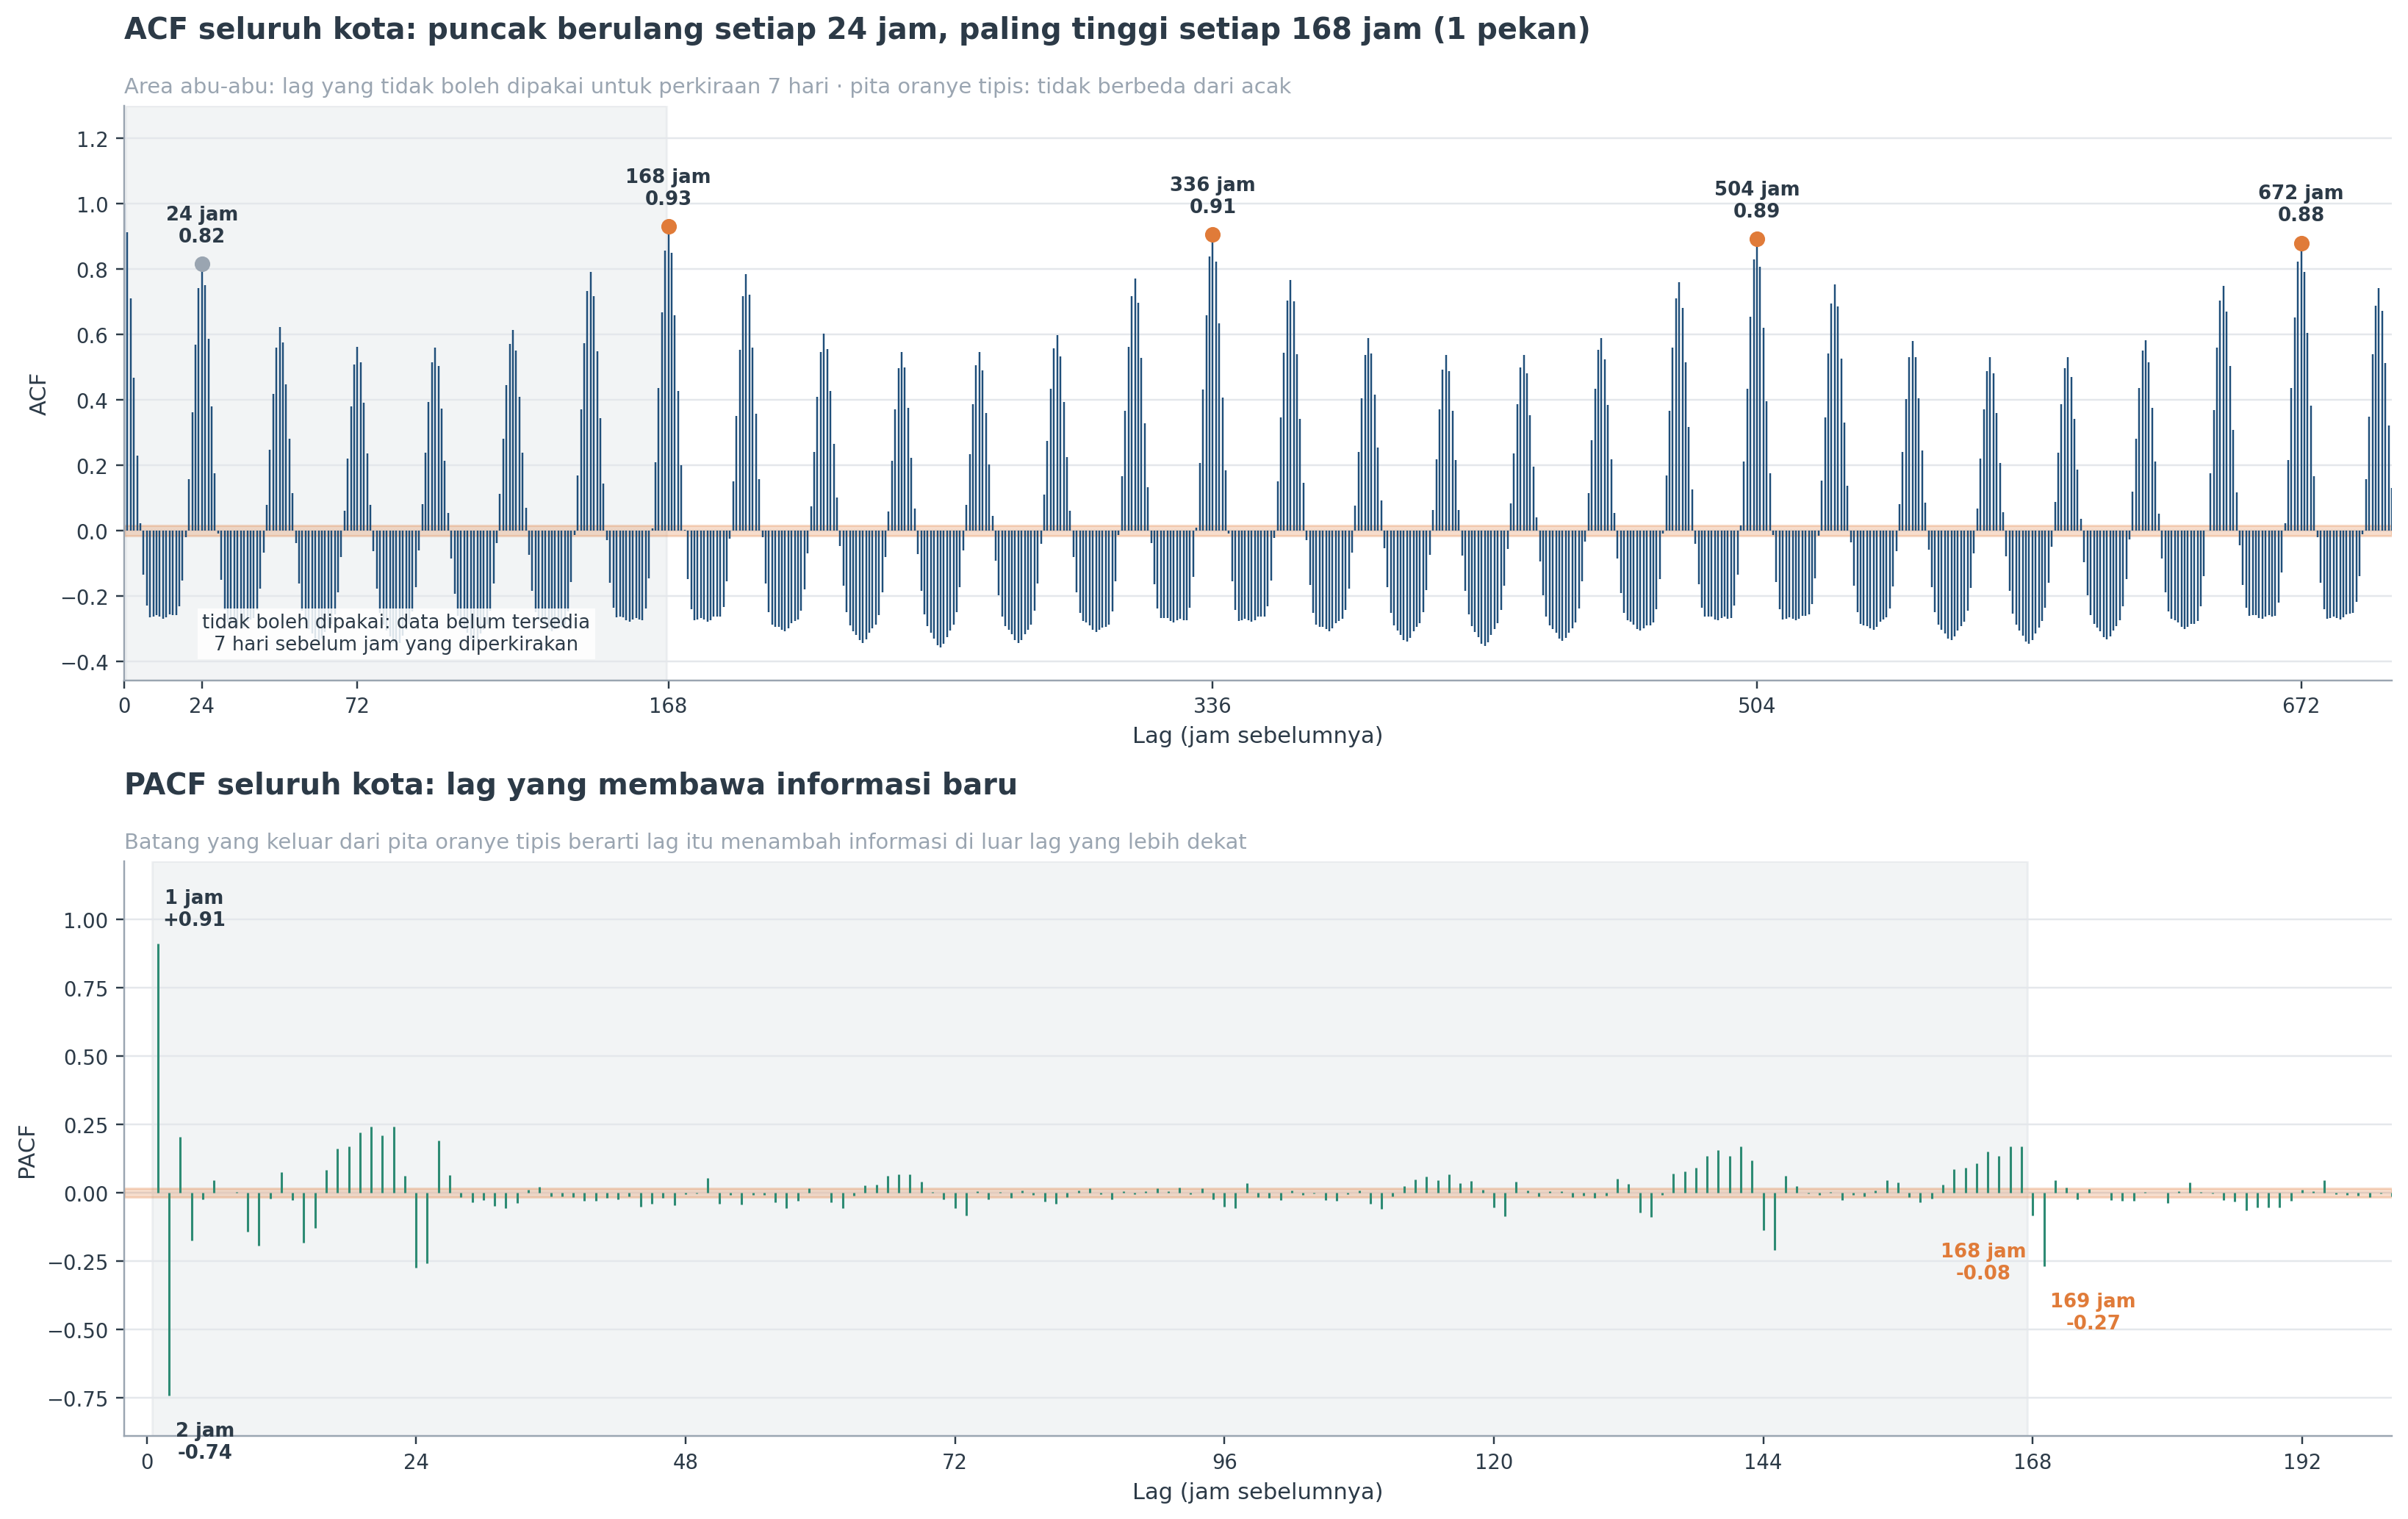

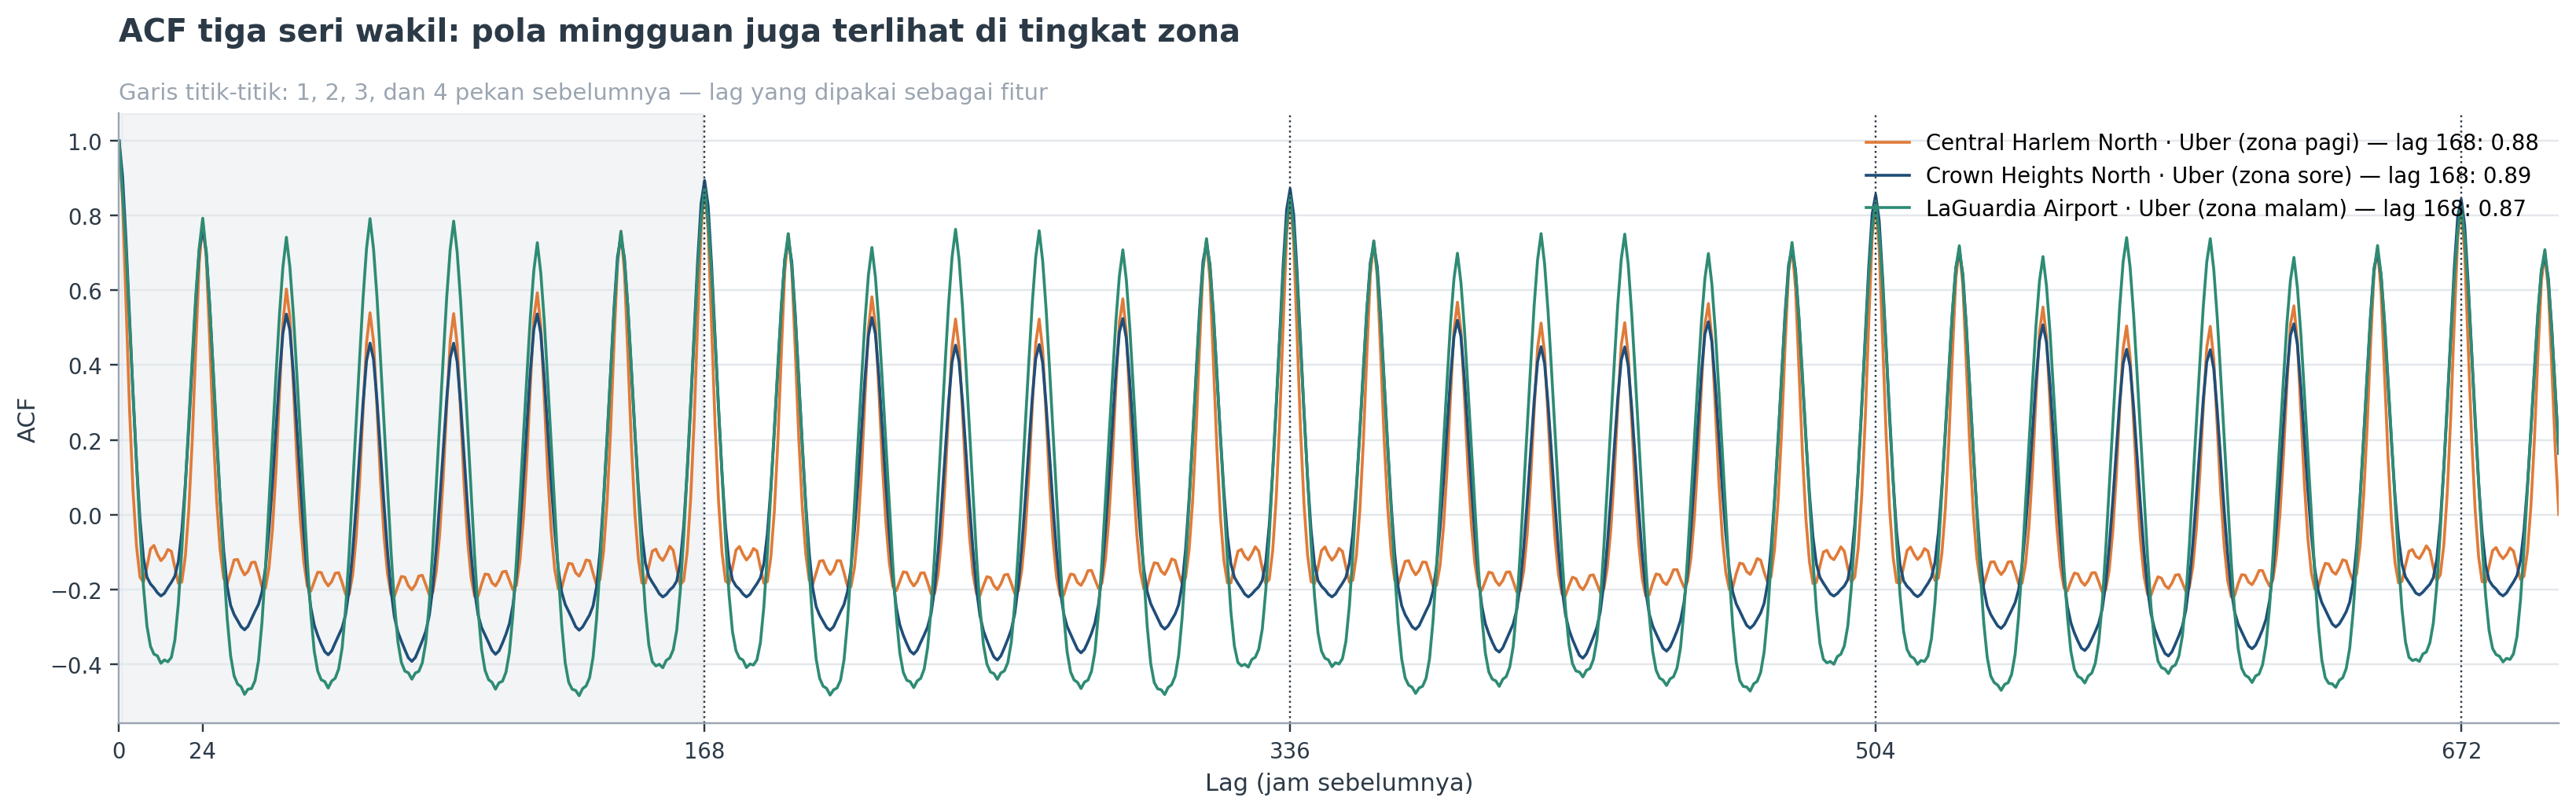

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9.5))

# ---------- ACF seluruh kota ----------
ax = axes[0]
r = ACF_HASIL["Seluruh kota"]
ax.axvspan(0.5, 167.5, color=C["muted"], alpha=0.12, zorder=0)
ax.text(84, min(r.min(), 0) - 0.02, "tidak boleh dipakai: data belum tersedia\n7 hari sebelum jam yang diperkirakan",
        ha="center", va="bottom", fontsize=8.5, color=C["text"],
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2))
ax.vlines(np.arange(LAG_ACF + 1), 0, r, color=C["primary"], linewidth=0.8)
ax.axhspan(-BATAS_ACAK, BATAS_ACAK, color=C["secondary"], alpha=0.25)
for k in [24, 168, 336, 504, 672]:
    ax.scatter([k], [r[k]], color=C["secondary"] if k >= 168 else C["muted"], s=35, zorder=5)
    ax.annotate(f"{k} jam\n{r[k]:.2f}", xy=(k, r[k]), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8.5, color=C["text"], fontweight="semibold")
ax.set_xlim(0, LAG_ACF)
ax.set_ylim(min(r.min(), 0) - 0.1, 1.3)
ax.set_xticks([0, 24, 72, 168, 336, 504, 672])
ax.set_xlabel("Lag (jam sebelumnya)")
ax.set_ylabel("ACF")
titled(ax, "ACF seluruh kota: puncak berulang setiap 24 jam, paling tinggi setiap 168 jam (1 pekan)",
       "Area abu-abu: lag yang tidak boleh dipakai untuk perkiraan 7 hari · pita oranye tipis: tidak berbeda dari acak")
clean_axes(ax)

# ---------- PACF seluruh kota ----------
ax = axes[1]
ax.vlines(np.arange(1, LAG_PACF + 1), 0, PACF_KOTA[1:], color=C["accent"], linewidth=1)
ax.axhspan(-BATAS_ACAK, BATAS_ACAK, color=C["secondary"], alpha=0.25)
ax.axvspan(0.5, 167.5, color=C["muted"], alpha=0.12, zorder=0)
# Tandai lag sah (168 dan 169) dan lag terdekat terbesar sebagai pembanding
for k in [1, 2, 168, 169]:
    atas = PACF_KOTA[k] > 0
    geser = {1: 16, 2: 16, 168: -22, 169: 22}[k]
    ax.annotate(f"{k} jam\n{PACF_KOTA[k]:+.2f}", xy=(k, PACF_KOTA[k]), xytext=(geser, 8 if atas else -28),
                textcoords="offset points", ha="center", fontsize=8.5,
                color=C["secondary"] if k >= 168 else C["text"], fontweight="semibold")
ax.set_xlim(-2, LAG_PACF)
ax.set_ylim(min(PACF_KOTA[1:].min(), 0) - 0.15, max(PACF_KOTA[1:].max(), 0) + 0.3)
ax.set_xticks([0, 24, 48, 72, 96, 120, 144, 168, 192])
ax.set_xlabel("Lag (jam sebelumnya)")
ax.set_ylabel("PACF")
titled(ax, "PACF seluruh kota: lag yang membawa informasi baru",
       "Batang yang keluar dari pita oranye tipis berarti lag itu menambah informasi di luar lag yang lebih dekat")
clean_axes(ax)
plt.tight_layout()
plt.show()

# ---------- ACF tiga seri wakil ----------
fig, ax = plt.subplots(figsize=(15, 4.8))
warna = [C["secondary"], C["primary"], C["accent"]]
for (n, r2), w in zip([(n, v) for n, v in ACF_HASIL.items() if n != "Seluruh kota"], warna):
    ax.plot(np.arange(LAG_ACF + 1), r2, color=w, linewidth=1.2, label=f"{n} — lag 168: {r2[168]:.2f}")
ax.axvspan(0.5, 167.5, color=C["muted"], alpha=0.12, zorder=0)
for k in [168, 336, 504, 672]:
    ax.axvline(k, color=C["text"], linestyle=":", linewidth=0.8)
ax.set_xlim(0, LAG_ACF)
ax.set_xticks([0, 24, 168, 336, 504, 672])
ax.set_xlabel("Lag (jam sebelumnya)")
ax.set_ylabel("ACF")
ax.legend(loc="upper right", fontsize=9)
titled(ax, "ACF tiga seri wakil: pola mingguan juga terlihat di tingkat zona",
       "Garis titik-titik: 1, 2, 3, dan 4 pekan sebelumnya — lag yang dipakai sebagai fitur")
clean_axes(ax)
plt.tight_layout()
plt.show()

> **Cara membaca grafik Step 5B**

**ACF seluruh kota** — setiap garis tegak adalah satu lag. Tinggi garis menunjukkan seberapa mirip permintaan sekarang dengan permintaan sekian jam sebelumnya. Area abu-abu di kiri (lag di bawah 168 jam) adalah informasi yang tidak boleh dipakai, karena perkiraan dibuat sampai 7 hari ke depan. Titik oranye menandai lag 1, 2, 3, dan 4 pekan — lag yang dipakai sebagai fitur. Pita oranye tipis di sekitar 0 adalah batas "tidak berbeda dari acak".

**PACF seluruh kota** — mirip ACF, tetapi hanya menunjukkan informasi *baru* dari setiap lag, setelah pengaruh lag-lag yang lebih dekat disingkirkan. Batang yang menonjol keluar dari pita oranye menandai lag yang layak dipakai.

**ACF tiga seri wakil** — ACF yang sama untuk satu seri dari masing-masing kelompok zona. Bila puncaknya juga berada di 168, 336, 504, dan 672 jam, pemilihan lag berlaku bukan hanya untuk kota, tetapi juga untuk tiap zona.

> **Hasil Step 5B**

*Diisi setelah dijalankan: lag sah dengan ACF tertinggi, lag dengan PACF terbesar, dan apakah pola yang sama terlihat di ketiga seri wakil.*

---

# STEP 6 — Pembanding Sederhana

**Tujuan:** menghitung kesalahan tiga cara sederhana, sebagai batas yang wajib dikalahkan model.

| Pembanding | Cara menebak |
|---|---|
| Angka pekan lalu | Permintaan jam yang sama 168 jam lalu |
| Rata-rata 4 pekan | Rata-rata jam yang sama 4 pekan terakhir |
| Rata-rata zona per jam | Rata-rata jam yang sama di seluruh periode sebelumnya |

**Pembanding terbaik dipilih pada periode validasi**, bukan pada periode uji, agar penilaian akhir tetap jujur.

**Cara interpretasi:** pada data uji, angka pekan lalu seharusnya mendekati 22,1 dari 100 seperti di Business Analytics (sedikit berbeda karena di sini jam kosong ikut dinilai).

In [11]:
def tambah_rata_zona_jam(df, sebelumnya):
    r = (pd.concat(sebelumnya).groupby(["provider", "zona", "jam_hari"], observed=True)["demand"]
         .mean().rename("tebak_rata_zona_jam").reset_index())
    df = df.drop(columns=["tebak_rata_zona_jam"], errors="ignore").merge(r, on=["provider", "zona", "jam_hari"], how="left")
    df["tebak_rata_zona_jam"] = df["tebak_rata_zona_jam"].fillna(0)
    return df


val = tambah_rata_zona_jam(val, [latih])
uji = tambah_rata_zona_jam(uji, [latih, val])

PEMBANDING = {"tebak_pekan_lalu": "Angka pekan lalu", "tebak_rata_4pekan": "Rata-rata 4 pekan",
              "tebak_rata_zona_jam": "Rata-rata zona per jam"}

pb_val = tabel_ukur(val, PEMBANDING)
pb_uji = tabel_ukur(uji, PEMBANDING)
PB_TERBAIK = pb_val["WMAPE"].idxmin()
KOLOM_PB = {v: k for k, v in PEMBANDING.items()}[PB_TERBAIK]

print("Periode validasi:")
display(pb_val.style.format(FORMAT_UKUR))
print("Periode uji (hanya dilihat, tidak dipakai memilih):")
display(pb_uji.style.format(FORMAT_UKUR))
print(f"Pembanding terbaik, dipilih pada validasi : {PB_TERBAIK}")
print(f"Angka pekan lalu pada uji, hanya jam berperjalanan : "
      f"{ukur(uji.loc[uji['demand'] > 0, 'demand'], uji.loc[uji['demand'] > 0, 'tebak_pekan_lalu'])['WMAPE']:.1f} dari 100")

Periode validasi:


,WMAPE,MAE,RMSE,Bias %,Rasio MAE
Angka pekan lalu,22.0,16.90,33.40,+0.8%,1.000
Rata-rata 4 pekan,18.5,14.20,28.39,-0.8%,0.840
Rata-rata zona per jam,26.4,20.28,37.29,-5.7%,1.200


Periode uji (hanya dilihat, tidak dipakai memilih):


,WMAPE,MAE,RMSE,Bias %,Rasio MAE
Angka pekan lalu,21.3,16.44,30.75,-0.6%,1.000
Rata-rata 4 pekan,18.5,14.24,26.01,-0.2%,0.866
Rata-rata zona per jam,27.1,20.84,36.50,-5.2%,1.268


Pembanding terbaik, dipilih pada validasi : Rata-rata 4 pekan
Angka pekan lalu pada uji, hanya jam berperjalanan : 21.3 dari 100


---

# STEP 7 — Lima Kandidat Model

**Tujuan:** membandingkan beberapa model dan memilih yang terbaik secara jujur.

**Kenapa lebih dari satu model:** tidak ada model yang pasti terbaik untuk semua data. Kandidat dibedakan dari dua sisi — jenis model, dan apakah satu model dipakai untuk semua seri atau dipisah.

| Kandidat | Jenis | Dipakai untuk | Pertanyaan yang dijawab |
|---|---|---|---|
| Regresi linear | Garis lurus dari fitur | Semua seri | Apakah hubungan sederhana sudah cukup? |
| LightGBM satu model | Pohon keputusan bertingkat | Semua seri | Apakah pola rumit membantu? |
| LightGBM satu model + fitur tren | Sama, ditambah fitur tahun lalu | Semua seri | Apakah informasi tahun lalu membantu? |
| LightGBM per kelompok seri | Satu model untuk tiap kelompok seri | Seri ramai dan sepi dipisah | Apakah seri ramai dan sepi perlu model sendiri? |
| LightGBM per provider | Satu model untuk Uber, satu untuk Lyft | Provider dipisah | Apakah Uber dan Lyft perlu model sendiri? |

**Aturan memilih:** semua kandidat dilatih pada periode latih dan dinilai pada periode validasi.

1. Kandidat dengan bias lebih dari ±3% tidak boleh dipilih, karena perkiraannya selalu terlalu tinggi atau terlalu rendah
2. Dari sisanya, dipilih yang WMAPE-nya terkecil
3. Kandidat yang selisih WMAPE-nya kurang dari 0,1 poin dianggap setara; di antara yang setara dipilih yang paling sederhana, karena lebih mudah dijelaskan dan dirawat

Urutan dari paling sederhana: regresi linear, LightGBM satu model, satu model + tren, per kelompok seri, per provider.

**Waktu:** setiap kandidat LightGBM dapat butuh beberapa menit. Log `[200] validasi's wmape` muncul berkala selama pelatihan.

In [12]:
FITUR_DASAR_NUM = ["lag_1pekan", "lag_2pekan", "lag_3pekan", "lag_4pekan", "rata_jam_sama_4pekan",
                   "rata_1hari", "rata_1pekan", "rata_4pekan",
                   "jam_hari", "hari", "bulan", "libur", "malam_akhir_pekan"]
FITUR_TREN = ["lag_52pekan", "rata_4pekan_tahun_lalu", "rasio_tren"]
FITUR_DASAR = FITUR_DASAR_NUM + KAT

PARAM = {"objective": "tweedie", "tweedie_variance_power": 1.2, "metric": "None",
         "learning_rate": 0.05, "num_leaves": 255, "min_data_in_leaf": 200,
         "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1,
         "lambda_l2": 1.0, "max_cat_to_onehot": 8, "verbose": -1, "seed": 42}
PUTARAN = 3000


def _wmape_lgb(p, d):
    y = d.get_label()
    return "wmape", np.abs(y - p).sum() / y.sum(), False


def _kat(fitur):
    return [f for f in fitur if f in KAT]


# ---------- LightGBM: satu model atau dipisah per kolom ----------
def lgb_latih(df_l, df_v, fitur, pisah=None):
    grup = [None] if pisah is None else [g for g in df_l[pisah].cat.categories if (df_l[pisah] == g).any()]
    st = {"jenis": "lgb", "fitur": fitur, "pisah": pisah, "model": {}, "iter": {}}
    for g in grup:
        a = df_l if g is None else df_l[df_l[pisah] == g]
        b = df_v if g is None else df_v[df_v[pisah] == g]
        d_l = lgb.Dataset(a[fitur], a["demand"], categorical_feature=_kat(fitur))
        d_v = lgb.Dataset(b[fitur], b["demand"], categorical_feature=_kat(fitur), reference=d_l)
        m = lgb.train(PARAM, d_l, num_boost_round=PUTARAN, valid_sets=[d_v],
                      valid_names=["validasi"], feval=_wmape_lgb,
                      callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)])
        st["model"][g], st["iter"][g] = m, m.best_iteration
        print(f"    {'semua seri' if g is None else f'{pisah} = {g}'} : iterasi terbaik {m.best_iteration}")
    return st


def lgb_latih_ulang(st, df):
    baru = dict(st, model={})
    for g, it in st["iter"].items():
        a = df if g is None else df[df[st["pisah"]] == g]
        baru["model"][g] = lgb.train(PARAM, lgb.Dataset(a[st["fitur"]], a["demand"],
                                     categorical_feature=_kat(st["fitur"])), num_boost_round=it)
    return baru


def lgb_tebak(st, df):
    hasil = np.zeros(len(df))
    for g, m in st["model"].items():
        idx = np.ones(len(df), bool) if g is None else (df[st["pisah"]] == g).to_numpy()
        if idx.any():
            hasil[idx] = m.predict(df.loc[idx, st["fitur"]], num_iteration=st["iter"][g])
    return np.clip(hasil, 0, None)


# ---------- Regresi linear (ridge), dihitung bertahap agar hemat memori ----------
LIN_NUM = ["lag_1pekan", "lag_2pekan", "lag_3pekan", "lag_4pekan", "rata_jam_sama_4pekan",
           "rata_1hari", "rata_1pekan", "rata_4pekan", "libur", "malam_akhir_pekan"]


def _matriks(df):
    num = np.column_stack([df[k].to_numpy(np.float32) for k in LIN_NUM])
    isi = np.nan_to_num(df["rata_4pekan"].to_numpy(np.float32))
    num = np.nan_to_num(np.where(np.isnan(num), isi[:, None], num))
    jam = np.eye(24, dtype=np.float32)[df["jam_hari"].to_numpy().astype(int)][:, 1:]
    hari = np.eye(7, dtype=np.float32)[df["hari"].to_numpy().astype(int) - 1][:, 1:]
    prov = (df["provider"].astype(str).to_numpy() == KAT_NILAI["provider"][0]).astype(np.float32)[:, None]
    kj = np.column_stack([(df["kelompok_jam"].astype(str).to_numpy() == g)
                          for g in KAT_NILAI["kelompok_jam"][1:]]).astype(np.float32)
    return np.hstack([np.ones((len(df), 1), np.float32), num, jam, hari, prov, kj])


def lin_latih(df_l, df_v=None, lam=1.0, blok=500_000):
    xtx, xty = None, None
    for i in range(0, len(df_l), blok):
        X = _matriks(df_l.iloc[i:i + blok]).astype(np.float64)
        y = df_l["demand"].to_numpy(np.float64)[i:i + blok]
        xtx = X.T @ X if xtx is None else xtx + X.T @ X
        xty = X.T @ y if xty is None else xty + X.T @ y
    reg = lam * np.eye(xtx.shape[0]); reg[0, 0] = 0
    return {"jenis": "linear", "koef": np.linalg.solve(xtx + reg, xty)}


def lin_tebak(st, df, blok=500_000):
    return np.clip(np.concatenate([_matriks(df.iloc[i:i + blok]) @ st["koef"]
                                   for i in range(0, len(df), blok)]), 0, None)


def tebak(st, df):
    return lin_tebak(st, df) if st["jenis"] == "linear" else lgb_tebak(st, df)


def latih_ulang(st, df):
    return lin_latih(df) if st["jenis"] == "linear" else lgb_latih_ulang(st, df)


KANDIDAT = {
    "Regresi linear":               lambda: lin_latih(latih),
    "LightGBM satu model":          lambda: lgb_latih(latih, val, FITUR_DASAR),
    "LightGBM satu model + tren":   lambda: lgb_latih(latih, val, FITUR_DASAR + FITUR_TREN),
    "LightGBM per kelompok seri":   lambda: lgb_latih(latih, val, FITUR_DASAR, pisah="kelompok_seri"),
    "LightGBM per provider":        lambda: lgb_latih(latih, val, FITUR_DASAR, pisah="provider"),
}

STATE_VAL, WAKTU = {}, {}
for nama, fungsi in KANDIDAT.items():
    print(f"\n>> {nama}")
    t0 = time.time()
    STATE_VAL[nama] = fungsi()
    val[f"tebak_{nama}"] = tebak(STATE_VAL[nama], val)
    WAKTU[nama] = (time.time() - t0) / 60
    print(f"   selesai {WAKTU[nama]:.1f} menit | validasi meleset "
          f"{ukur(val['demand'], val[f'tebak_{nama}'])['WMAPE']:.1f} dari 100")


>> Regresi linear
   selesai 0.0 menit | validasi meleset 18.4 dari 100

>> LightGBM satu model
[200]	validasi's wmape: 0.164883
[400]	validasi's wmape: 0.162716
[600]	validasi's wmape: 0.161905
[800]	validasi's wmape: 0.161512
    semua seri : iterasi terbaik 888
   selesai 1.9 menit | validasi meleset 16.1 dari 100

>> LightGBM satu model + tren
    semua seri : iterasi terbaik 85
   selesai 0.4 menit | validasi meleset 15.7 dari 100

>> LightGBM per kelompok seri
[200]	validasi's wmape: 0.155669
[400]	validasi's wmape: 0.154272
[600]	validasi's wmape: 0.153895
[800]	validasi's wmape: 0.153795
    kelompok_seri = 1 : iterasi terbaik 789
[200]	validasi's wmape: 0.173009
    kelompok_seri = 2 : iterasi terbaik 279
[200]	validasi's wmape: 0.201936
    kelompok_seri = 3 : iterasi terbaik 176
   selesai 1.6 menit | validasi meleset 16.4 dari 100

>> LightGBM per provider
[200]	validasi's wmape: 0.189634
    provider = Lyft : iterasi terbaik 187
[200]	validasi's wmape: 0.157101
[400]	vali

In [13]:
SEMUA_VAL = {f"tebak_{n}": n for n in KANDIDAT} | PEMBANDING
hasil_val = tabel_ukur(val, SEMUA_VAL)
hasil_val["Waktu latih (menit)"] = pd.Series(WAKTU)
hasil_val["Jenis"] = ["Kandidat"] * len(KANDIDAT) + ["Pembanding"] * len(PEMBANDING)

# Aturan memilih:
# 1. Kandidat dengan bias lebih dari ±3% tidak boleh dipilih, karena selalu terlalu tinggi atau rendah
# 2. Dari sisanya, dipilih WMAPE terkecil
# 3. Kandidat dengan selisih WMAPE kurang dari 0,1 poin dianggap setara;
#    di antara yang setara dipilih yang paling sederhana
KESEDERHANAAN = {n: i for i, n in enumerate(KANDIDAT)}   # urutan di KANDIDAT = dari paling sederhana
kand = hasil_val.loc[list(KANDIDAT)]
layak = kand[kand["Bias %"].abs() <= BATAS_BIAS]
if layak.empty:
    layak = kand
dekat = layak[layak["WMAPE"] - layak["WMAPE"].min() < BATAS_SETARA]
TERPILIH = min(dekat.index, key=KESEDERHANAAN.get)

print("Periode validasi, Oktober–Desember 2025:\n")
display(hasil_val.sort_values("WMAPE").style.format({**FORMAT_UKUR, "WMAPE": "{:.2f}", "Waktu latih (menit)": "{:.1f}"}, na_rep="—"))
print(f"Kandidat dengan bias melebihi ±{BATAS_BIAS:.0f}% (tidak boleh dipilih): {list(kand.index.difference(layak.index)) or 'tidak ada'}")
print(f"Kandidat setara dengan yang terbaik (selisih < {BATAS_SETARA} poin): {list(dekat.index)}")
print(f"\nMODEL TERPILIH : {TERPILIH}")
print(f"  meleset {hasil_val.loc[TERPILIH, 'WMAPE']:.1f} dari 100, bias {hasil_val.loc[TERPILIH, 'Bias %']:+.1f}%")
print(f"  pembanding terbaik ({PB_TERBAIK}) meleset {hasil_val.loc[PB_TERBAIK, 'WMAPE']:.1f} dari 100")

Periode validasi, Oktober–Desember 2025:



,WMAPE,MAE,RMSE,Bias %,Rasio MAE,Waktu latih (menit),Jenis
LightGBM satu model + tren,15.74,12.09,22.57,-1.5%,0.716,0.4,Kandidat
LightGBM satu model,16.14,12.40,23.65,-1.7%,0.734,1.9,Kandidat
LightGBM per provider,16.27,12.50,23.83,-1.6%,0.739,1.8,Kandidat
LightGBM per kelompok seri,16.37,12.57,23.86,-2.1%,0.744,1.6,Kandidat
Regresi linear,18.41,14.14,27.94,-0.8%,0.837,0.0,Kandidat
Rata-rata 4 pekan,18.48,14.20,28.39,-0.8%,0.840,—,Pembanding
Angka pekan lalu,22.00,16.90,33.40,+0.8%,1.000,—,Pembanding
Rata-rata zona per jam,26.40,20.28,37.29,-5.7%,1.200,—,Pembanding


Kandidat dengan bias melebihi ±3% (tidak boleh dipilih): tidak ada
Kandidat setara dengan yang terbaik (selisih < 0.1 poin): ['LightGBM satu model + tren']

MODEL TERPILIH : LightGBM satu model + tren
  meleset 15.7 dari 100, bias -1.5%
  pembanding terbaik (Rata-rata 4 pekan) meleset 18.5 dari 100


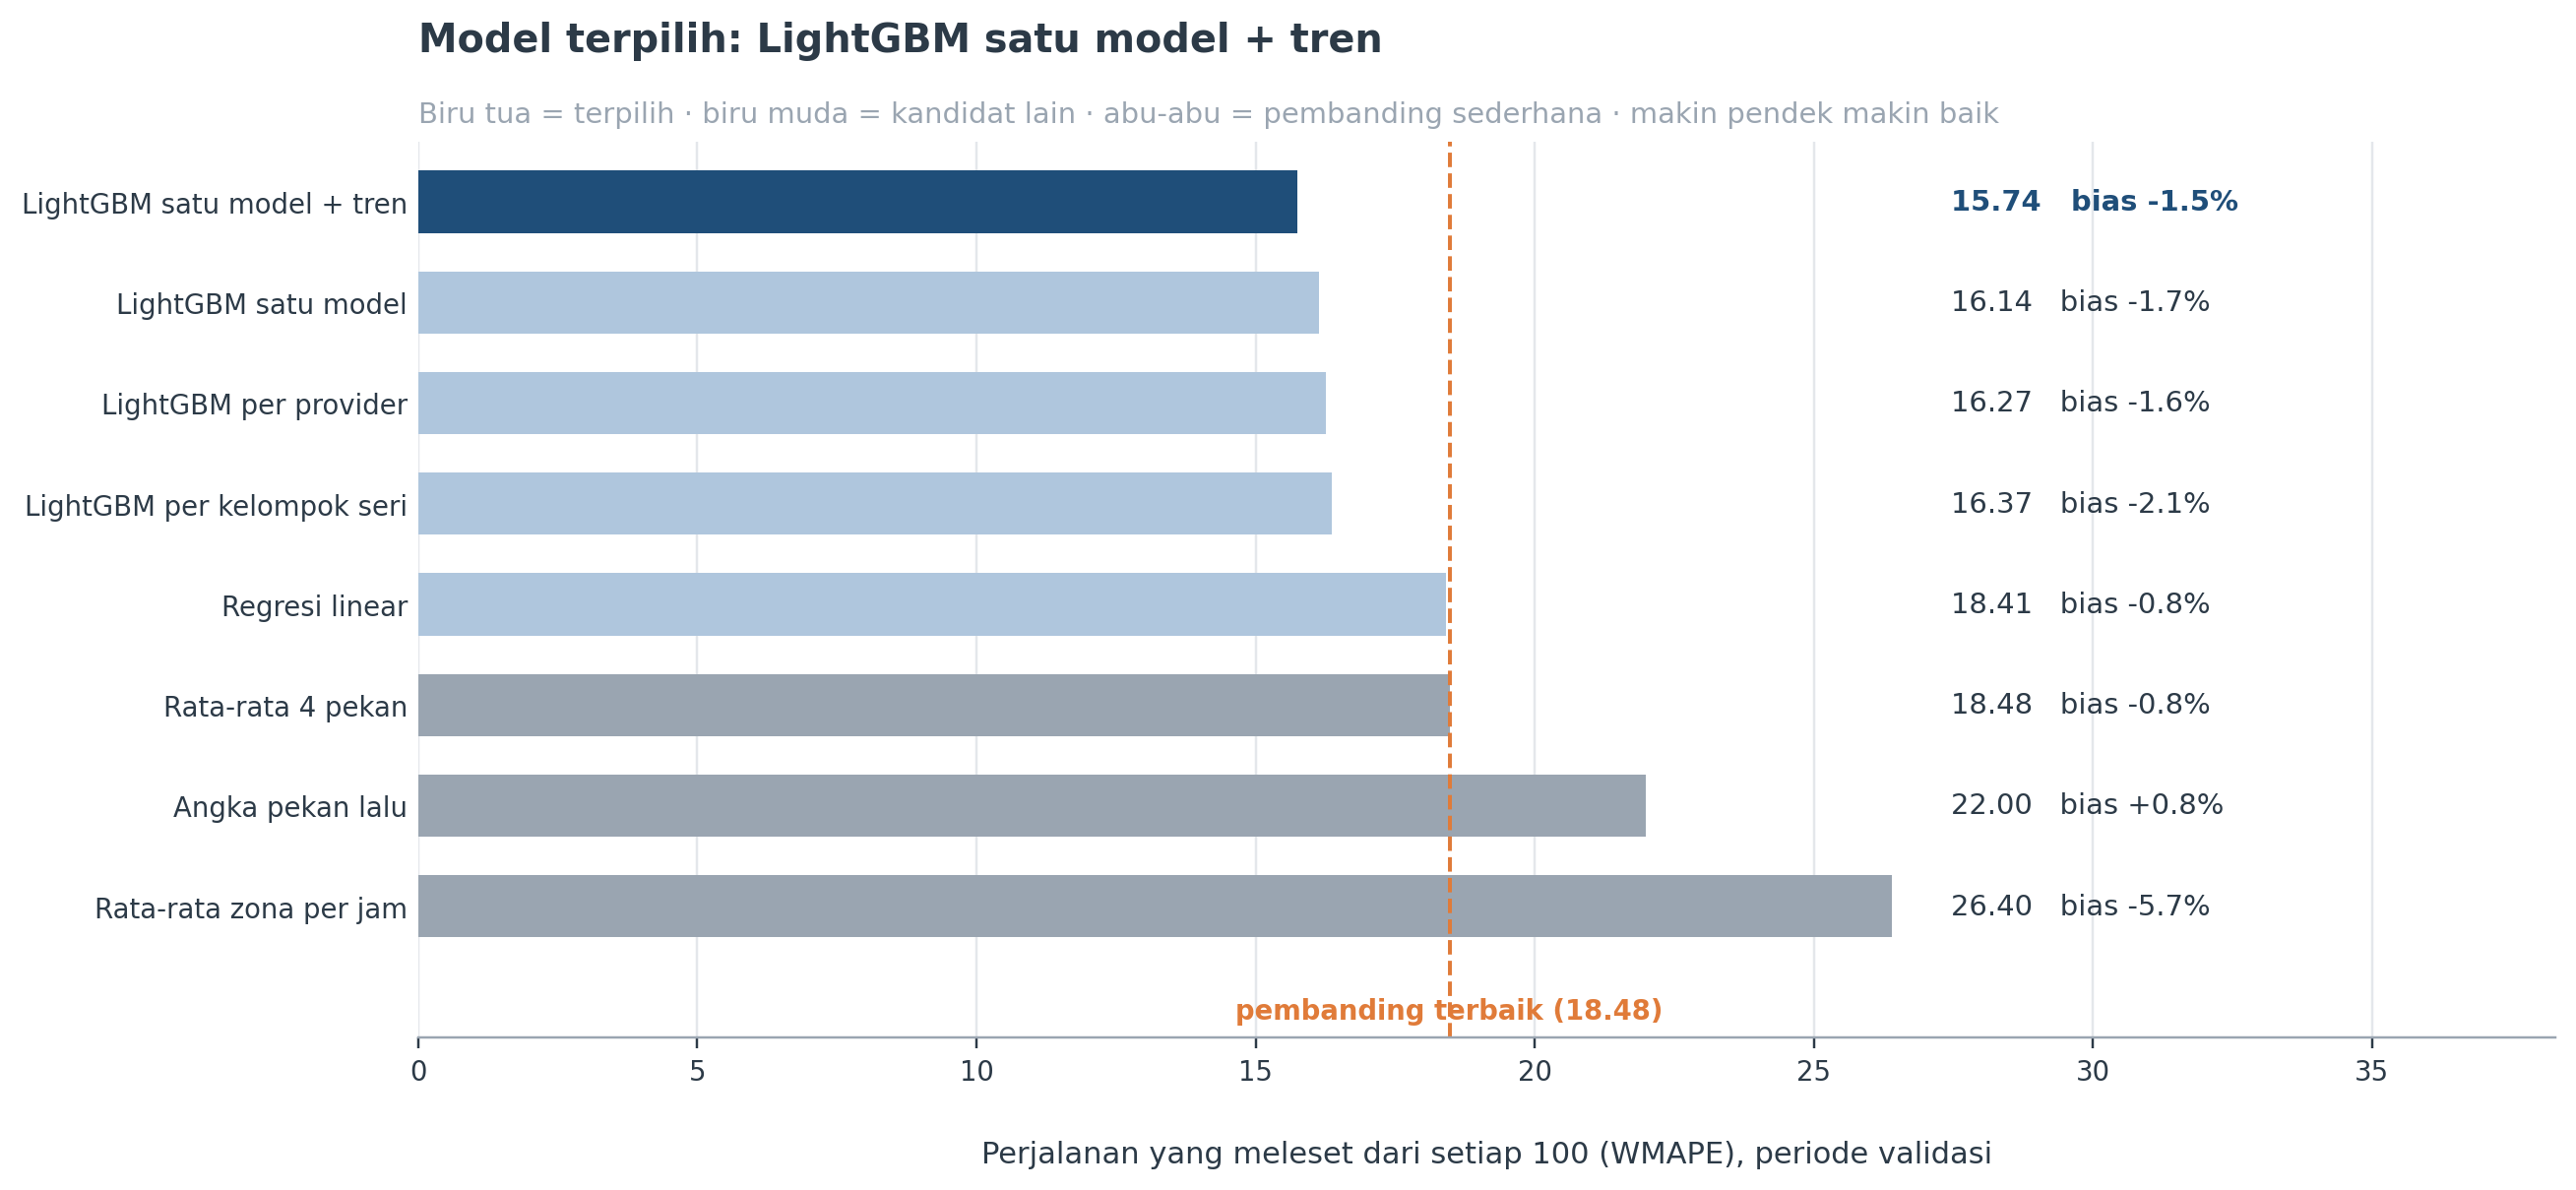

In [14]:
urut = hasil_val.sort_values("WMAPE", ascending=False)
warna = [C["primary"] if n == TERPILIH else (C["muted"] if j == "Pembanding" else C["band"])
         for n, j in zip(urut.index, urut["Jenis"])]

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.barh(urut.index, urut["WMAPE"], color=warna, height=0.62)
batas_x = urut["WMAPE"].max() * 1.45
for i, (v, b) in enumerate(zip(urut["WMAPE"], urut["Bias %"])):
    ax.text(urut["WMAPE"].max() * 1.04, i, f"{v:.2f}   bias {b:+.1f}%", va="center", fontsize=9.5,
            color=C["primary"] if urut.index[i] == TERPILIH else C["text"],
            fontweight="bold" if urut.index[i] == TERPILIH else "normal")
x_pb = hasil_val.loc[PB_TERBAIK, "WMAPE"]
ax.axvline(x_pb, color=C["secondary"], linestyle="--", linewidth=1.3)
ax.text(x_pb, -0.9, f"pembanding terbaik ({x_pb:.2f})", color=C["secondary"], fontsize=9,
        ha="center", va="top", fontweight="semibold")
ax.set_xlim(0, batas_x)
ax.set_ylim(-1.3, len(urut) - 0.4)
ax.set_xlabel("Perjalanan yang meleset dari setiap 100 (WMAPE), periode validasi", labelpad=18)
titled(ax, f"Model terpilih: {TERPILIH}",
       "Biru tua = terpilih · biru muda = kandidat lain · abu-abu = pembanding sederhana · makin pendek makin baik")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

> **Cara membaca grafik dan tabel Step 7**

Setiap batang adalah satu cara menebak, dinilai pada periode validasi Oktober–Desember 2025. Panjang batang adalah jumlah perjalanan yang meleset dari setiap 100 — makin pendek makin baik. Angka bias di samping batang menunjukkan apakah cara itu cenderung terlalu tinggi (positif) atau terlalu rendah (negatif). Garis putus-putus oranye adalah pembanding sederhana terbaik: kandidat yang batangnya melewati garis ini tidak lebih baik dari cara sederhana.

Tabel memuat seluruh ukuran kesalahan. Model dipilih hanya dari hasil validasi; hasil uji baru dilihat di step berikutnya.

> **Hasil Step 7**

*Diisi setelah dijalankan: model terpilih, alasan pemilihan, dan apakah memisah model per kelompok atau per provider membantu.*

---

# STEP 8 — Penilaian pada Periode Uji

**Tujuan:** menilai model terpilih sekali pada Januari–Mei 2026.

**Cara:** model terpilih dilatih ulang pada latih + validasi dengan jumlah iterasi yang sama, lalu menebak periode uji. Hasil uji kandidat lain juga ditampilkan untuk keterbukaan, tetapi tidak dipakai untuk memilih.

**Cara interpretasi:** model berhasil bila kesalahannya lebih kecil dari pembanding terbaik di seluruh seri dan di setiap kelompok seri, dengan bias mendekati 0.

In [15]:
t0 = time.time()
latih_val = pd.concat([latih, val.drop(columns=[c for c in val.columns if c.startswith("tebak_") and c not in PEMBANDING])],
                      ignore_index=True)
STATE_UJI = latih_ulang(STATE_VAL[TERPILIH], latih_val)
uji["perkiraan"] = tebak(STATE_UJI, uji)
print(f"Latih ulang {TERPILIH} selesai dalam {(time.time() - t0) / 60:.1f} menit\n")

# Kandidat lain: model hasil latih saja, untuk keterbukaan
for n in KANDIDAT:
    uji[f"tebak_{n}"] = uji["perkiraan"] if n == TERPILIH else tebak(STATE_VAL[n], uji)

UTAMA = {"perkiraan": f"Model terpilih ({TERPILIH})", **PEMBANDING}
hasil_uji = tabel_ukur(uji, UTAMA)
print("Periode uji, Januari–Mei 2026:")
display(hasil_uji.style.format(FORMAT_UKUR))

m, b = hasil_uji.iloc[0]["WMAPE"], hasil_uji.loc[PB_TERBAIK, "WMAPE"]
print(f"Model meleset {m:.1f} dari 100, pembanding terbaik ({PB_TERBAIK}) {b:.1f} dari 100 "
      f"-> kesalahan {'berkurang' if m < b else 'bertambah'} {abs(1 - m / b) * 100:.0f}%")

print("\nSemua kandidat pada periode uji (tidak dipakai memilih):")
display(tabel_ukur(uji, {f"tebak_{n}": n for n in KANDIDAT}).sort_values("WMAPE").style.format(FORMAT_UKUR))

Latih ulang LightGBM satu model + tren selesai dalam 0.2 menit

Periode uji, Januari–Mei 2026:


,WMAPE,MAE,RMSE,Bias %,Rasio MAE
Model terpilih (LightGBM satu model + tren),16.4,12.62,22.89,-1.2%,0.767
Angka pekan lalu,21.3,16.44,30.75,-0.6%,1.000
Rata-rata 4 pekan,18.5,14.24,26.01,-0.2%,0.866
Rata-rata zona per jam,27.1,20.84,36.50,-5.2%,1.268


Model meleset 16.4 dari 100, pembanding terbaik (Rata-rata 4 pekan) 18.5 dari 100 -> kesalahan berkurang 11%

Semua kandidat pada periode uji (tidak dipakai memilih):


,WMAPE,MAE,RMSE,Bias %,Rasio MAE
LightGBM satu model,16.1,12.38,22.27,-1.8%,0.753
LightGBM per provider,16.2,12.45,22.37,-1.7%,0.757
LightGBM per kelompok seri,16.3,12.52,22.42,-2.0%,0.762
LightGBM satu model + tren,16.4,12.62,22.89,-1.2%,0.767
Regresi linear,18.1,13.97,25.44,-0.3%,0.850


In [16]:
BANDING = {"perkiraan": "Model", "tebak_pekan_lalu": "Angka pekan lalu",
           "tebak_rata_4pekan": "Rata-rata 4 pekan", "tebak_rata_zona_jam": "Rata-rata zona per jam"}
NAMA_PB = {"Angka pekan lalu": "Angka pekan lalu", "Rata-rata 4 pekan": "Rata-rata 4 pekan",
           "Rata-rata zona per jam": "Rata-rata zona per jam"}[PB_TERBAIK]

per_kelompok = wmape_per(uji, BANDING, "kelompok_seri")
per_kelompok["Selisih model − pembanding"] = per_kelompok["Model"] - per_kelompok[NAMA_PB]
per_kelompok["Kesimpulan"] = np.select(
    [per_kelompok["Selisih model − pembanding"] <= -BATAS_POIN, per_kelompok["Selisih model − pembanding"] >= BATAS_POIN],
    ["Model lebih baik", "Model lebih buruk"], "Setara")
per_kelompok.index = [f"Kelompok {k}" for k in per_kelompok.index]
print(f"Meleset dari setiap 100, per kelompok seri (pembanding: {PB_TERBAIK}):")
display(per_kelompok.style.format({c: "{:.1f}" for c in BANDING.values()} | {"Selisih model − pembanding": "{:+.1f}"}))

for kol, judul in [("provider", "provider"), ("kelompok_jam", "kelompok jam zona")]:
    print(f"Per {judul}:")
    display(wmape_per(uji, BANDING, kol).style.format("{:.1f}"))

# Konsistensi per pekan
uji["pekan"] = uji["jam"].dt.to_period("W-SUN").dt.start_time
pp = uji.groupby(["kelompok_seri", "pekan"], observed=True).apply(
    lambda g: pd.Series({"model": ukur(g["demand"], g["perkiraan"])["WMAPE"],
                         "pb": ukur(g["demand"], g[KOLOM_PB])["WMAPE"]})).reset_index()
pp["selisih"] = pp["model"] - pp["pb"]
konsisten = pp.groupby("kelompok_seri", observed=True)["selisih"].agg(
    jumlah_pekan="count", rata_selisih="mean",
    model_menang=lambda s: int((s <= -BATAS_POIN).sum()), setara=lambda s: int((s.abs() < BATAS_POIN).sum()),
    model_kalah=lambda s: int((s >= BATAS_POIN).sum()))
konsisten.index = [f"Kelompok {k}" for k in konsisten.index]
print(f"Konsistensi per pekan, model dibanding {PB_TERBAIK}:")
display(konsisten.style.format({"rata_selisih": "{:+.1f}"}))

Meleset dari setiap 100, per kelompok seri (pembanding: Rata-rata 4 pekan):


,Model,Angka pekan lalu,Rata-rata 4 pekan,Rata-rata zona per jam,Selisih model − pembanding,Kesimpulan
Kelompok 1,15.0,20.0,17.4,26.4,-2.3,Model lebih baik
Kelompok 2,17.7,22.6,19.6,27.3,-1.9,Model lebih baik
Kelompok 3,20.9,26.0,22.3,30.5,-1.5,Model lebih baik


Per provider:


,Model,Angka pekan lalu,Rata-rata 4 pekan,Rata-rata zona per jam
provider,,,,
Lyft,20.0,24.9,21.8,31.3
Uber,15.2,20.1,17.4,25.6


Per kelompok jam zona:


,Model,Angka pekan lalu,Rata-rata 4 pekan,Rata-rata zona per jam
kelompok_jam,,,,
pagi,16.0,20.5,17.7,24.8
siang,18.0,22.6,20.0,27.5
sore,16.0,20.9,18.2,25.8
malam,17.4,23.1,20.0,32.0


Konsistensi per pekan, model dibanding Rata-rata 4 pekan:


,jumlah_pekan,rata_selisih,model_menang,setara,model_kalah
Kelompok 1,22,-2.6,11,11,0
Kelompok 2,22,-2.0,13,9,0
Kelompok 3,22,-1.6,11,11,0


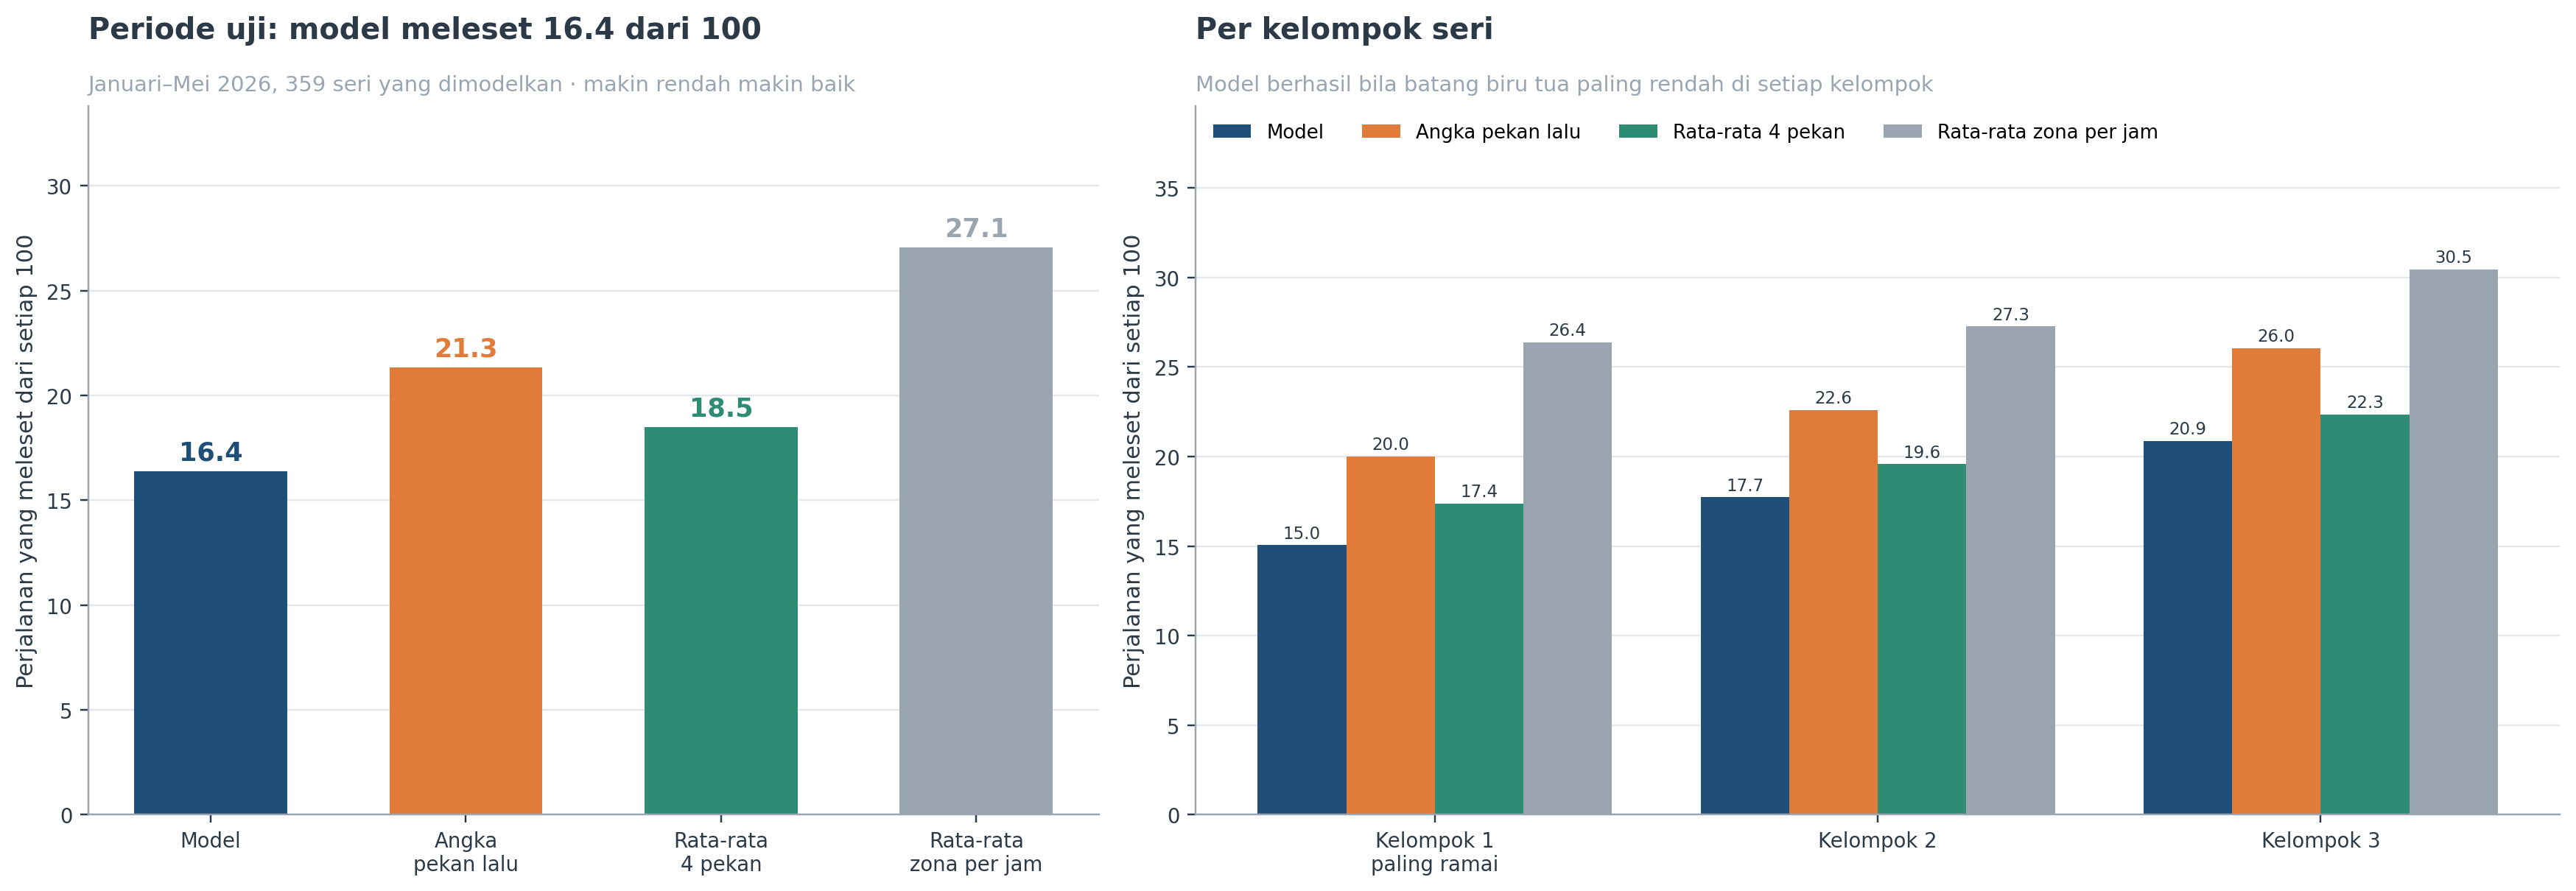

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), gridspec_kw={"width_ratios": [1, 1.35]})
WARNA = {"Model": C["primary"], "Angka pekan lalu": C["secondary"],
         "Rata-rata 4 pekan": C["accent"], "Rata-rata zona per jam": C["muted"]}

ax = axes[0]
nilai = [ukur(uji["demand"], uji[k])["WMAPE"] for k in BANDING]
nama = list(BANDING.values())
ax.bar(range(len(nama)), nilai, color=[WARNA[n] for n in nama], width=0.6)
for i, v in enumerate(nilai):
    ax.text(i, v + max(nilai) * 0.02, f"{v:.1f}", ha="center", fontsize=11.5, fontweight="bold", color=WARNA[nama[i]])
ax.set_xticks(range(len(nama)))
ax.set_xticklabels(["Model", "Angka\npekan lalu", "Rata-rata\n4 pekan", "Rata-rata\nzona per jam"])
ax.set_ylim(0, max(nilai) * 1.25)
ax.set_ylabel("Perjalanan yang meleset dari setiap 100")
titled(ax, f"Periode uji: model meleset {nilai[0]:.1f} dari 100",
       "Januari–Mei 2026, 359 seri yang dimodelkan · makin rendah makin baik")
clean_axes(ax)

ax = axes[1]
lebar, xk = 0.2, np.arange(len(per_kelompok))
for j, n in enumerate(nama):
    v = per_kelompok[n].values
    ax.bar(xk + (j - 1.5) * lebar, v, width=lebar, color=WARNA[n], label=n)
    for xi, vi in zip(xk + (j - 1.5) * lebar, v):
        ax.text(xi, vi + 0.4, f"{vi:.1f}", ha="center", fontsize=7.5, color=C["text"])
ax.set_xticks(xk)
ax.set_xticklabels([f"{k}\n{'paling ramai' if i == 0 else ''}" for i, k in enumerate(per_kelompok.index)])
ax.set_ylim(0, per_kelompok[nama].values.max() * 1.3)
ax.set_ylabel("Perjalanan yang meleset dari setiap 100")
ax.legend(loc="upper left", ncol=4, fontsize=8.5)
titled(ax, "Per kelompok seri", "Model berhasil bila batang biru tua paling rendah di setiap kelompok")
clean_axes(ax)
plt.tight_layout()
plt.show()

> **Cara membaca grafik Step 8**

**Kiri** — kesalahan model dan tiga pembanding pada Januari–Mei 2026. Tinggi batang adalah jumlah perjalanan yang meleset dari setiap 100.

**Kanan** — kesalahan yang sama, dipisah per kelompok seri. Kelompok 1 berisi seri paling ramai. Bila batang biru tua paling rendah di setiap kelompok, keunggulan model tidak hanya berasal dari seri ramai.

> **Hasil Step 8**

*Diisi setelah dijalankan: kesalahan model dibanding pembanding terbaik, bias, hasil per kelompok seri, dan konsistensi per pekan.*

---

# STEP 8B — Apakah Sisa Kesalahan Masih Berpola?

**Tujuan:** memeriksa apakah model sudah menangkap pola waktu, dengan menghitung ACF dari **sisa kesalahan** (kenyataan dikurangi perkiraan) pada periode uji.

**Cara interpretasi:**

| Lag | Bila ACF sisa kesalahan tinggi | Artinya |
|---|---|---|
| 1–24 jam | Wajar | Kesalahan jam ini mirip jam sebelumnya, karena model tidak boleh memakai data 7 hari terakhir |
| 168 jam (1 pekan) | Masalah | Pola mingguan belum tertangkap sepenuhnya |

Bila ACF sisa kesalahan pada lag 168 jauh lebih kecil daripada ACF permintaan pada lag 168, model sudah menangkap pola mingguan.

Periode uji, 359 seri dimodelkan:


,Kota: permintaan,Kota: sisa kesalahan,Rata-rata seri: permintaan,Rata-rata seri: sisa kesalahan
Lag,,,,
1 jam,0.918,0.916,0.853,0.620
2 jam,0.724,0.799,0.665,0.504
24 jam,0.772,0.235,0.704,0.244
168 jam,0.863,-0.063,0.789,-0.010
336 jam,0.805,-0.139,0.731,-0.052


Lag 168 jam, rata-rata seri: permintaan 0.79 -> sisa kesalahan -0.01


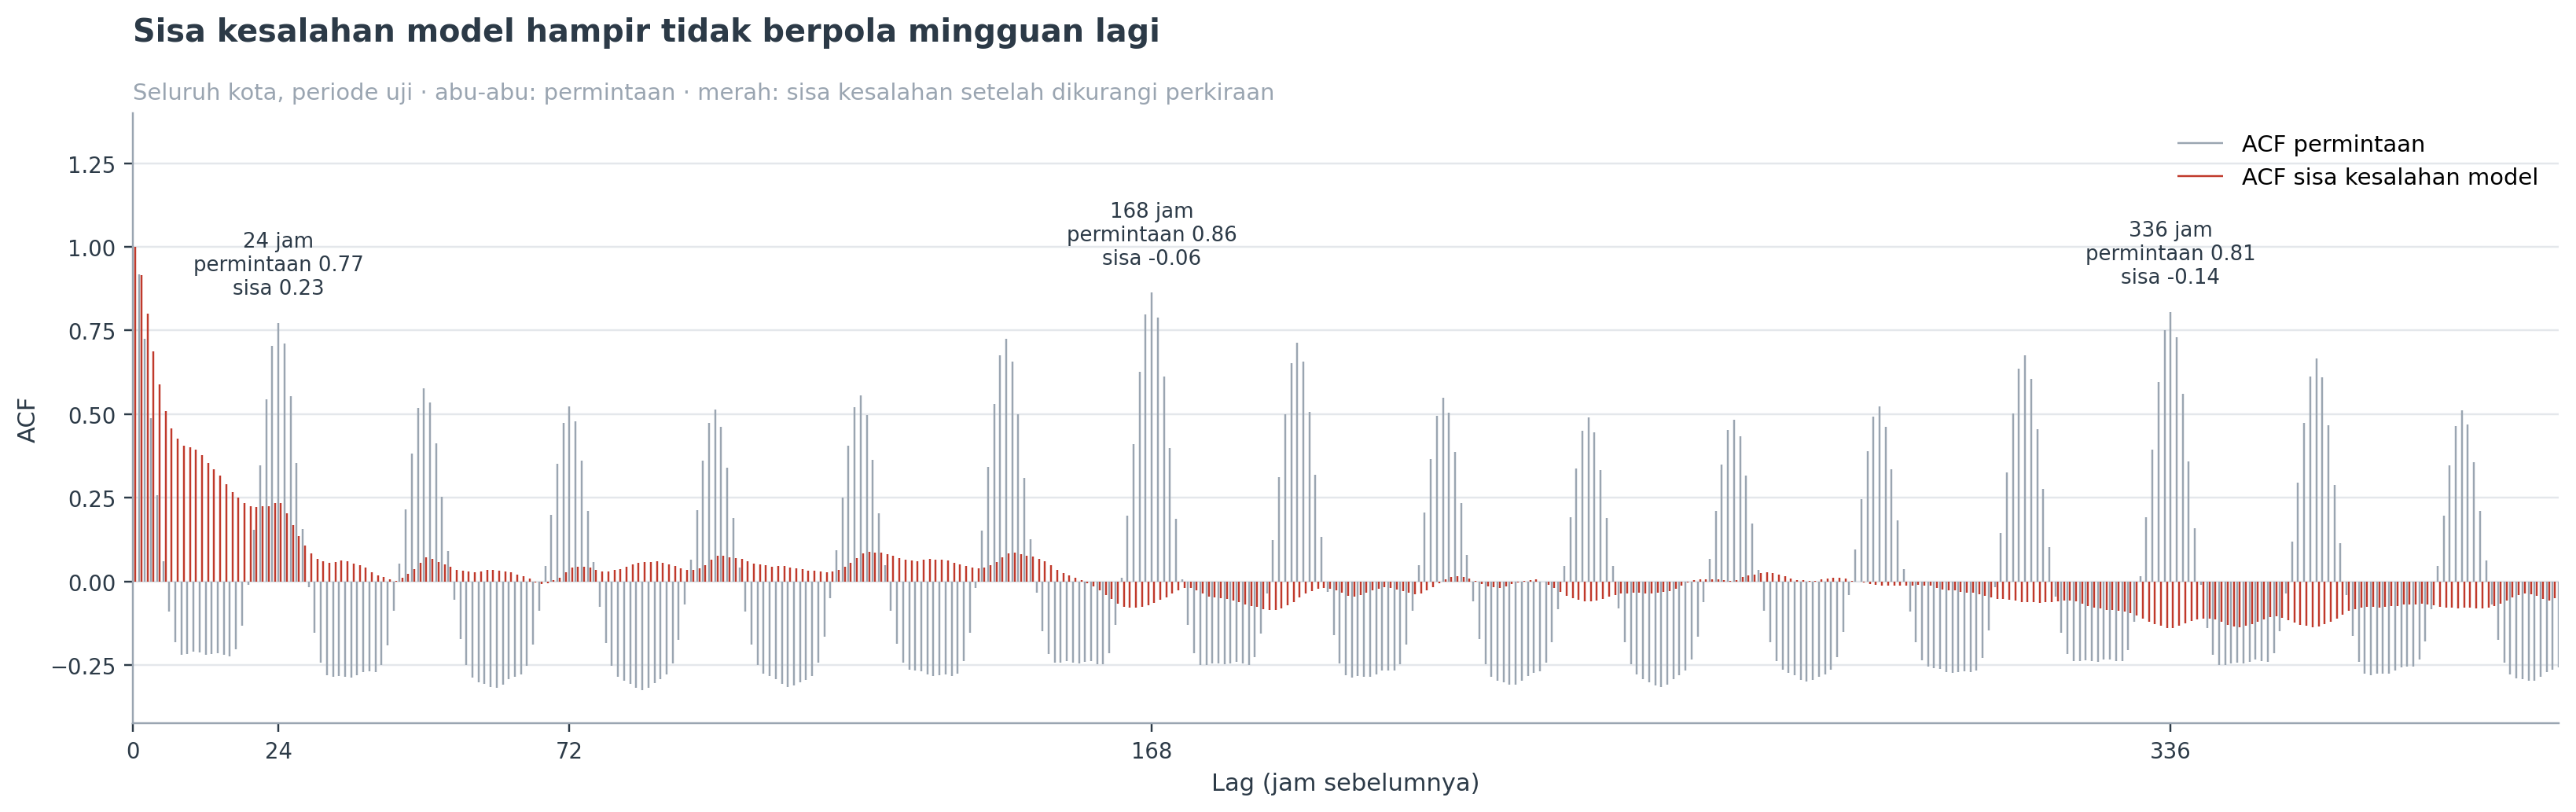

In [18]:
def acf_lag(x, lags):
    x = np.asarray(x, dtype=float); x = x - x.mean(); d = (x * x).sum()
    return np.array([(x[:-k] * x[k:]).sum() / d if d > 0 else np.nan for k in lags])


LAG_SISA = [1, 2, 24, 168, 336]
u = uji.sort_values(["provider", "zona", "jam"])

# Seluruh kota
kota_u = u.groupby("jam")[["demand", "perkiraan"]].sum()
acf_kota_dem = acf(kota_u["demand"], 400)
acf_kota_sisa = acf(kota_u["demand"] - kota_u["perkiraan"], 400)

# Rata-rata per seri, ditimbang jumlah perjalanan
per_seri = []
for (p, z), g in u.groupby(["provider", "zona"], observed=True):
    if g["demand"].sum() > 0:
        per_seri.append((g["demand"].sum(), acf_lag(g["demand"], LAG_SISA),
                         acf_lag(g["demand"] - g["perkiraan"], LAG_SISA)))
bobot = np.array([b for b, _, _ in per_seri])
rata_dem = np.nansum([b * a for b, a, _ in per_seri], axis=0) / bobot.sum()
rata_sisa = np.nansum([b * s for b, _, s in per_seri], axis=0) / bobot.sum()

tabel_sisa = pd.DataFrame({
    "Kota: permintaan": acf_kota_dem[LAG_SISA], "Kota: sisa kesalahan": acf_kota_sisa[LAG_SISA],
    "Rata-rata seri: permintaan": rata_dem, "Rata-rata seri: sisa kesalahan": rata_sisa,
}, index=[f"{k} jam" for k in LAG_SISA])
tabel_sisa.index.name = "Lag"
print(f"Periode uji, {len(per_seri)} seri dimodelkan:")
display(tabel_sisa.style.format("{:.3f}"))
print(f"Lag 168 jam, rata-rata seri: permintaan {rata_dem[3]:.2f} -> sisa kesalahan {rata_sisa[3]:.2f}")

fig, ax = plt.subplots(figsize=(15, 4.8))
lg = np.arange(401)
ax.vlines(lg, 0, acf_kota_dem, color=C["muted"], linewidth=0.8, label="ACF permintaan")
ax.vlines(lg + 0.4, 0, acf_kota_sisa, color=C["alert"], linewidth=0.8, label="ACF sisa kesalahan model")
for k in [24, 168, 336]:
    ax.annotate(f"{k} jam\npermintaan {acf_kota_dem[k]:.2f}\nsisa {acf_kota_sisa[k]:.2f}", xy=(k, acf_kota_dem[k]),
                xytext=(0, 12), textcoords="offset points", ha="center", fontsize=8.5, color=C["text"])
ax.set_xlim(0, 400)
ax.set_ylim(min(acf_kota_dem.min(), acf_kota_sisa.min()) - 0.1, 1.4)
ax.set_xticks([0, 24, 72, 168, 336])
ax.set_xlabel("Lag (jam sebelumnya)")
ax.set_ylabel("ACF")
ax.legend(loc="upper right")
titled(ax, "Sisa kesalahan model hampir tidak berpola mingguan lagi",
       "Seluruh kota, periode uji · abu-abu: permintaan · merah: sisa kesalahan setelah dikurangi perkiraan")
clean_axes(ax)
plt.tight_layout()
plt.show()

> **Cara membaca Step 8B**

Garis abu-abu adalah ACF permintaan: tinggi di lag 24 dan 168 karena permintaan berpola harian dan mingguan. Garis merah adalah ACF sisa kesalahan model. Bila garis merah di lag 168 jauh lebih rendah dari abu-abu, pola mingguan sudah diambil oleh model dan yang tersisa hanya kesalahan yang sulit ditebak. Garis merah yang masih tinggi di lag 1–24 wajar: kesalahan pada jam berurutan saling mirip, karena model memang tidak boleh memakai data 7 hari terakhir.

> **Hasil Step 8B**

*Diisi setelah dijalankan: ACF sisa kesalahan pada lag 24 dan 168, dibanding ACF permintaan.*

---

# STEP 9 — Batas Bawah dan Batas Atas

**Tujuan:** membuat batas bawah dan batas atas di sekitar perkiraan, lalu memeriksa apakah batas itu benar-benar mengapit sekitar 80% kenyataan.

**Cara membuatnya:** dari periode validasi, dihitung seberapa jauh kenyataan biasanya menyimpang dari perkiraan. Batas bawah adalah penyimpangan yang hanya dilampaui ke bawah 1 dari 10 kali, batas atas yang hanya dilampaui ke atas 1 dari 10 kali. Penyimpangan ini lalu diterapkan pada perkiraan baru.

| Tingkat | Cara | Alasan |
|---|---|---|
| Seri per jam | Penyimpangan dibagi akar perkiraan, dihitung per kelompok seri | Penyimpangan jam sepi dan jam ramai berbeda skala |
| Kota per jam, kota per hari, zona per hari | Rasio kenyataan terhadap perkiraan, dihitung pada tingkat itu sendiri | Menjumlahkan batas seri akan menghasilkan rentang yang terlalu lebar |

Seri di luar cakupan memakai rata-rata 4 pekan sebagai perkiraan, dengan batas yang dikalibrasi terpisah.

**Cara interpretasi:** cakupan pada periode uji seharusnya sekitar 80%. Jauh di bawah 80% berarti batas terlalu sempit; jauh di atas berarti terlalu lebar.

In [19]:
def gabung(df_model, df_luar, kolom_luar="tebak_rata_4pekan"):
    '''Perkiraan seluruh 524 seri: model untuk seri dimodelkan, rata-rata 4 pekan untuk sisanya.'''
    a = df_model[["provider", "zona", "jam", "demand", "perkiraan", "kelompok_seri"]].copy()
    a["kelompok_interval"] = "Kelompok " + a["kelompok_seri"].astype(str)
    b = df_luar[["provider", "zona", "jam", "demand", kolom_luar, "kelompok_seri"]].rename(columns={kolom_luar: "perkiraan"})
    b["kelompok_interval"] = "Di luar cakupan"
    g = pd.concat([a, b], ignore_index=True)
    for k in ["provider", "kelompok_seri"]:
        g[k] = g[k].astype(str)
    g["tanggal"] = g["jam"].dt.normalize()
    return g


val["perkiraan"] = val[f"tebak_{TERPILIH}"]
gab_val, gab_uji = gabung(val, luar_val), gabung(uji, luar_uji)

# ---------- Tingkat seri per jam ----------
def kalibrasi_seri(g):
    r = (g["demand"] - g["perkiraan"]) / np.sqrt(g["perkiraan"] + 1)
    return r.groupby(g["kelompok_interval"]).quantile([Q_BAWAH, Q_ATAS]).unstack()


def batas_seri(g, q):
    s = np.sqrt(g["perkiraan"] + 1)
    g["batas_bawah"] = np.clip(g["perkiraan"] + g["kelompok_interval"].map(q[Q_BAWAH]) * s, 0, None)
    g["batas_atas"] = g["perkiraan"] + g["kelompok_interval"].map(q[Q_ATAS]) * s
    return g


# ---------- Tingkat agregat ----------
TINGKAT = {"Kota per jam": ["jam"], "Kota per hari": ["tanggal"], "Zona per hari": ["zona", "tanggal"]}


def agregat(g, kunci):
    return g.groupby(kunci, observed=True)[["demand", "perkiraan"]].sum()


def kalibrasi_agregat(g, kunci):
    a = agregat(g, kunci)
    a = a[a["perkiraan"] >= 1]
    return (a["demand"] / a["perkiraan"]).quantile([Q_BAWAH, Q_ATAS])


def batas_agregat(a, q):
    a["batas_bawah"], a["batas_atas"] = a["perkiraan"] * q[Q_BAWAH], a["perkiraan"] * q[Q_ATAS]
    return a


def nilai_batas(y, lo, hi, p):
    return {"Cakupan": ((y >= lo) & (y <= hi)).mean() * 100,
            "Di bawah batas bawah": (y < lo).mean() * 100,
            "Di atas batas atas": (y > hi).mean() * 100,
            "Lebar rata-rata (% perkiraan)": ((hi - lo).sum() / p.sum()) * 100}


Q_SERI = kalibrasi_seri(gab_val)
Q_AGR = {n: kalibrasi_agregat(gab_val, k) for n, k in TINGKAT.items()}

gab_uji = batas_seri(gab_uji, Q_SERI)
cek = {"Seri per jam": nilai_batas(gab_uji["demand"], gab_uji["batas_bawah"], gab_uji["batas_atas"], gab_uji["perkiraan"])}
AGR_UJI = {}
for n, k in TINGKAT.items():
    a = batas_agregat(agregat(gab_uji, k), Q_AGR[n])
    AGR_UJI[n] = a
    cek[n] = nilai_batas(a["demand"], a["batas_bawah"], a["batas_atas"], a["perkiraan"])

print("Penyimpangan dari validasi, tingkat seri per jam (per akar perkiraan):")
display(Q_SERI.rename(columns={Q_BAWAH: "bawah", Q_ATAS: "atas"}).style.format("{:+.2f}"))
print("Rasio kenyataan / perkiraan dari validasi, tingkat agregat:")
display(pd.DataFrame(Q_AGR).T.rename(columns={Q_BAWAH: "bawah", Q_ATAS: "atas"}).style.format("{:.3f}"))
print("Periode uji: apakah batas mengapit sekitar 80% kenyataan?")
display(pd.DataFrame(cek).T.style.format("{:.1f}"))

Penyimpangan dari validasi, tingkat seri per jam (per akar perkiraan):


,bawah,atas
kelompok_interval,,
Di luar cakupan,-1.18,+1.53
Kelompok 1,-2.37,+2.56
Kelompok 2,-1.79,+2.02
Kelompok 3,-1.54,+1.75


Rasio kenyataan / perkiraan dari validasi, tingkat agregat:


,bawah,atas
Kota per jam,0.895,1.106
Kota per hari,0.941,1.095
Zona per hari,0.874,1.141


Periode uji: apakah batas mengapit sekitar 80% kenyataan?


,Cakupan,Di bawah batas bawah,Di atas batas atas,Lebar rata-rata (% perkiraan)
Seri per jam,77.9,11.3,10.8,47.2
Kota per jam,75.4,10.4,14.2,21.1
Kota per hari,74.2,13.2,12.6,15.3
Zona per hari,75.8,11.6,12.7,26.7


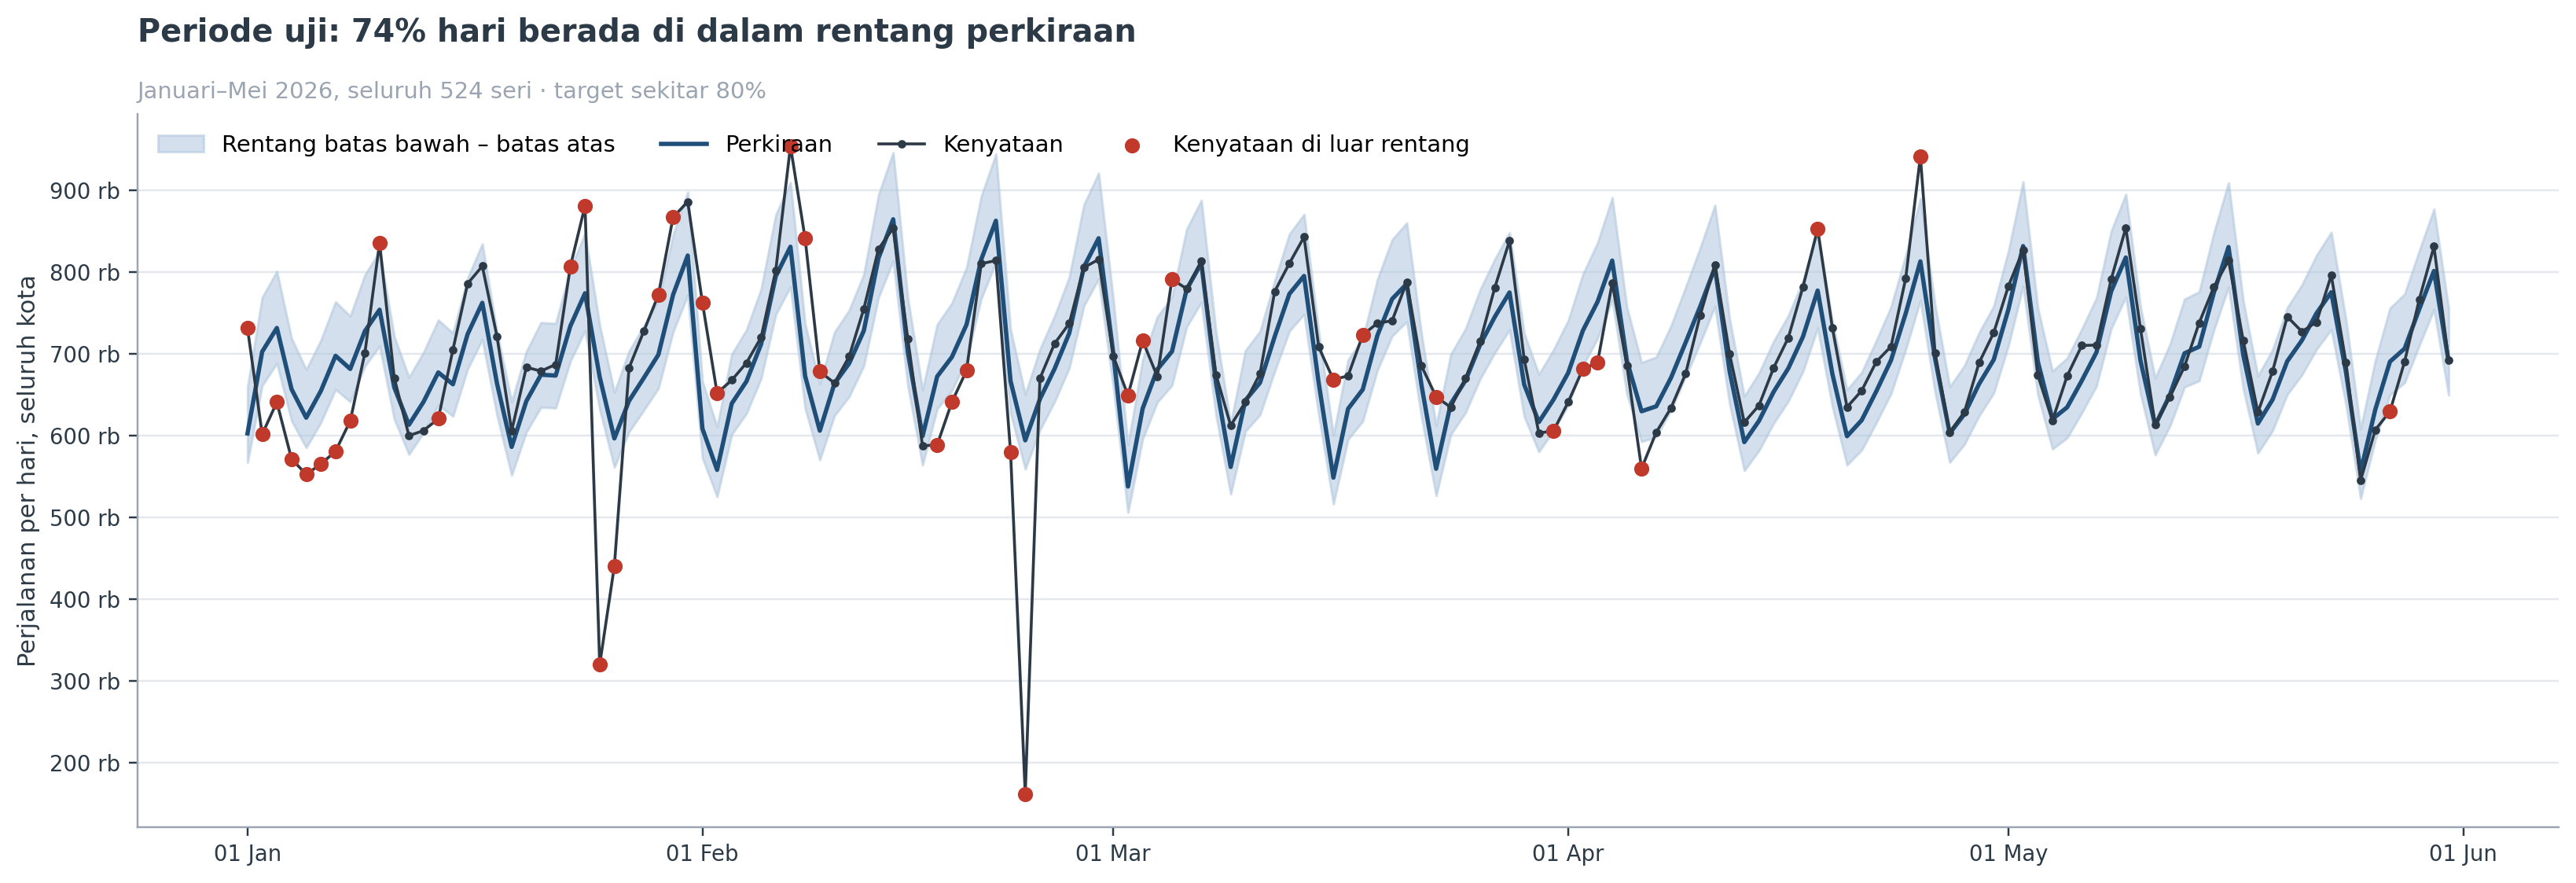

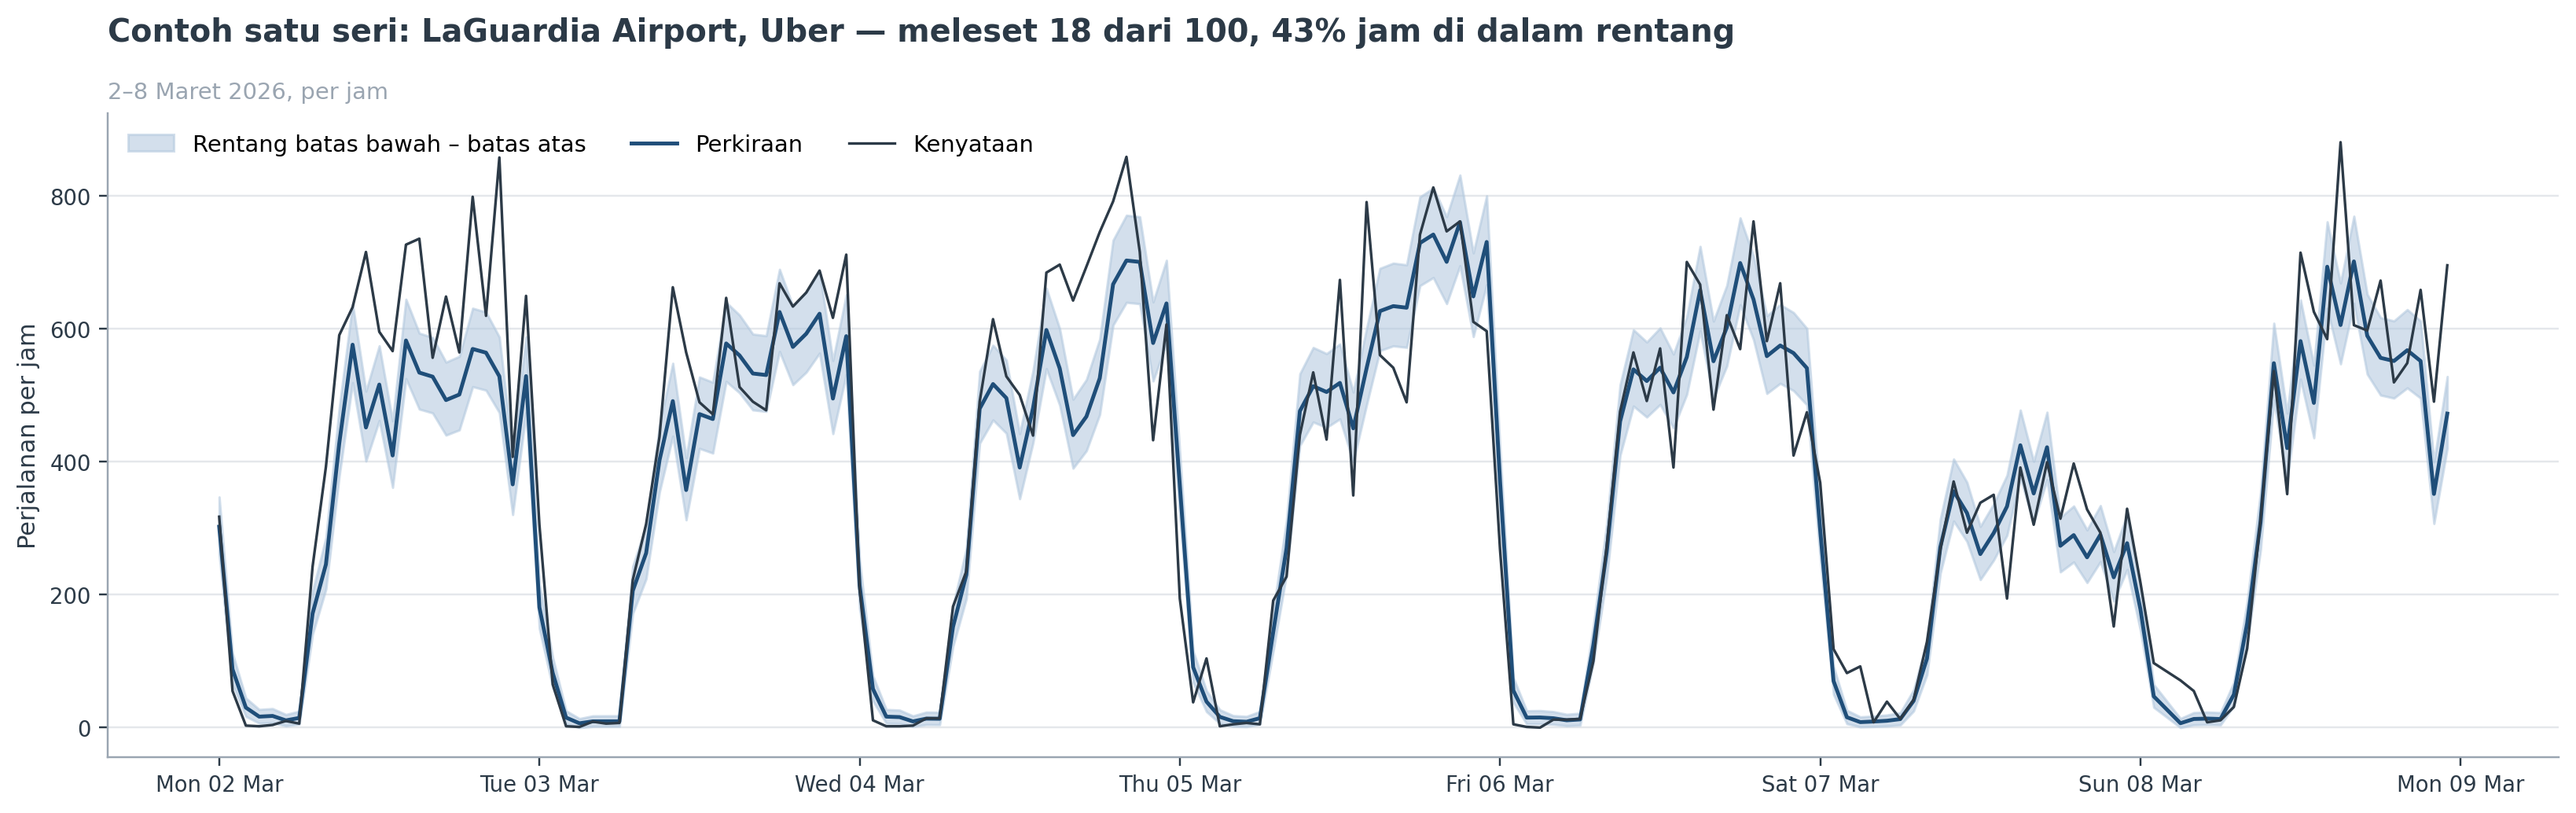

In [20]:
kh = AGR_UJI["Kota per hari"]
fig, ax = plt.subplots(figsize=(15, 5.2))
ax.fill_between(kh.index, kh["batas_bawah"], kh["batas_atas"], color=C["band"], alpha=0.55,
                label="Rentang batas bawah – batas atas")
ax.plot(kh.index, kh["perkiraan"], color=C["primary"], linewidth=1.8, label="Perkiraan")
ax.plot(kh.index, kh["demand"], color=C["text"], linewidth=1.2, marker="o", markersize=2.5, label="Kenyataan")
luar_rentang = kh[(kh["demand"] < kh["batas_bawah"]) | (kh["demand"] > kh["batas_atas"])]
ax.scatter(luar_rentang.index, luar_rentang["demand"], color=C["alert"], s=28, zorder=5,
           label="Kenyataan di luar rentang")
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.yaxis.set_major_formatter(RIBU)
ax.set_ylabel("Perjalanan per hari, seluruh kota")
ax.legend(loc="upper left", ncol=4)
titled(ax, f"Periode uji: {cek['Kota per hari']['Cakupan']:.0f}% hari berada di dalam rentang perkiraan",
       "Januari–Mei 2026, seluruh 524 seri · target sekitar 80%")
clean_axes(ax)
plt.tight_layout()
plt.show()

# Contoh satu seri: LaGuardia Airport, Uber, pekan 2–8 Maret 2026
ct = gab_uji[(gab_uji["zona"] == 138) & (gab_uji["provider"] == "Uber")
             & (gab_uji["jam"] >= "2026-03-02") & (gab_uji["jam"] < "2026-03-09")].sort_values("jam")
if len(ct):
    fig, ax = plt.subplots(figsize=(15, 4.8))
    ax.fill_between(ct["jam"], ct["batas_bawah"], ct["batas_atas"], color=C["band"], alpha=0.55,
                    label="Rentang batas bawah – batas atas")
    ax.plot(ct["jam"], ct["perkiraan"], color=C["primary"], linewidth=1.6, label="Perkiraan")
    ax.plot(ct["jam"], ct["demand"], color=C["text"], linewidth=1.1, label="Kenyataan")
    ax.set_ylabel("Perjalanan per jam")
    ax.legend(loc="upper left", ncol=3)
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
    wm = ukur(ct["demand"], ct["perkiraan"])["WMAPE"]
    cak = ((ct["demand"] >= ct["batas_bawah"]) & (ct["demand"] <= ct["batas_atas"])).mean() * 100
    titled(ax, f"Contoh satu seri: LaGuardia Airport, Uber — meleset {wm:.0f} dari 100, {cak:.0f}% jam di dalam rentang",
           "2–8 Maret 2026, per jam")
    clean_axes(ax)
    plt.tight_layout()
    plt.show()

> **Cara membaca grafik Step 9**

Step 9 adalah **ujian** untuk rentang perkiraan: model berpura-pura tidak tahu Januari–Mei 2026, lalu perkiraannya dibandingkan dengan kenyataan.

**Grafik atas** — setiap titik adalah satu hari, seluruh kota dijumlah. Garis biru adalah perkiraan, area biru muda adalah rentang dari batas bawah sampai batas atas, garis gelap adalah kenyataan. Titik merah adalah hari ketika kenyataan keluar dari rentang. Bila rentang dibuat dengan benar, sekitar 8 dari 10 hari berada di dalam area biru muda.

Hari yang anjlok sangat dalam — misalnya tinggal seperempat dari hari biasa — tidak dapat diperkirakan tanpa data cuaca atau kejadian. Karena model memakai angka pekan lalu, hari seperti itu juga menarik perkiraan **sepekan sesudahnya** ke bawah.

**Grafik bawah** — satu seri contoh, LaGuardia Airport untuk Uber, jam per jam selama satu pekan, dengan cara baca yang sama.

**Tabel cakupan** — untuk setiap tingkat (seri per jam, kota per jam, kota per hari, zona per hari): persen kenyataan di dalam rentang, di bawah batas bawah, di atas batas atas, dan lebar rentang dibanding perkiraan.

> **Hasil Step 9**

*Diisi setelah dijalankan: cakupan di setiap tingkat dan lebar rentang.*

---

# STEP 9B — Kalibrasi Ulang Rentang untuk Perkiraan Juni

**Tujuan:** memperbaiki rentang yang sedikit terlalu sempit pada Step 9.

**Masalah:** rentang dari Step 9 dikalibrasi hanya dari Oktober–Desember 2025. Pada periode uji, cakupannya 75–78%, sedikit di bawah target 80%.

**Perbaikan:** untuk perkiraan Juni, rentang dikalibrasi dari **Oktober 2025 sampai Mei 2026** — delapan bulan kesalahan yang semuanya berasal dari tebakan tanpa mengintip, karena tebakan periode uji dibuat oleh model yang tidak melihat data uji. Periode yang lebih panjang dan lebih baru membuat rentang lebih mewakili kondisi terkini.

**Pembuktian sebelum dipakai:** cara ini diuji lebih dulu — kalibrasi dari Oktober 2025–Maret 2026, lalu diperiksa pada April–Mei 2026, dan dibandingkan dengan kalibrasi lama.

In [21]:
PEMISAH = pd.Timestamp("2026-04-01")
cek_awal = pd.concat([gab_val, gab_uji[gab_uji["jam"] < PEMISAH]], ignore_index=True)
cek_akhir = gab_uji[gab_uji["jam"] >= PEMISAH].copy()


def cakupan(g, q_seri, q_agr):
    g = batas_seri(g.copy(), q_seri)
    hasil = {"Seri per jam": nilai_batas(g["demand"], g["batas_bawah"], g["batas_atas"], g["perkiraan"])["Cakupan"]}
    for n, k in TINGKAT.items():
        a = batas_agregat(agregat(g, k), q_agr[n])
        hasil[n] = nilai_batas(a["demand"], a["batas_bawah"], a["batas_atas"], a["perkiraan"])["Cakupan"]
    return hasil


q_s2 = kalibrasi_seri(cek_awal)
q_a2 = {n: kalibrasi_agregat(cek_awal, k) for n, k in TINGKAT.items()}
banding = pd.DataFrame({
    "Kalibrasi lama (Okt–Des)": cakupan(cek_akhir, Q_SERI, Q_AGR),
    "Kalibrasi baru (Okt–Mar)": cakupan(cek_akhir, q_s2, q_a2),
})
print("Cakupan pada April–Mei 2026 (target 80%):")
display(banding.style.format("{:.1f}%"))

# Kalibrasi akhir untuk perkiraan Juni: Oktober 2025 – Mei 2026
kal_akhir = pd.concat([gab_val, gab_uji], ignore_index=True)
Q_SERI_AKHIR = kalibrasi_seri(kal_akhir)
Q_AGR_AKHIR = {n: kalibrasi_agregat(kal_akhir, k) for n, k in TINGKAT.items()}
print("Rasio kenyataan / perkiraan, kalibrasi akhir:")
display(pd.DataFrame(Q_AGR_AKHIR).T.rename(columns={Q_BAWAH: "bawah", Q_ATAS: "atas"}).style.format("{:.3f}"))

Cakupan pada April–Mei 2026 (target 80%):


,Kalibrasi lama (Okt–Des),Kalibrasi baru (Okt–Mar)
Seri per jam,80.5%,82.4%
Kota per jam,86.6%,91.5%
Kota per hari,90.2%,96.7%
Zona per hari,84.7%,88.2%


Rasio kenyataan / perkiraan, kalibrasi akhir:


,bawah,atas
Kota per jam,0.894,1.120
Kota per hari,0.921,1.101
Zona per hari,0.867,1.156


> **Cara membaca Step 9B**

Tabel pertama membandingkan dua cara kalibrasi pada April–Mei 2026, dua bulan yang tidak dipakai oleh kalibrasi mana pun. Kolom yang cakupannya lebih dekat ke 80% adalah cara yang lebih baik. Tabel kedua adalah rasio akhir yang dipakai untuk perkiraan Juni: misalnya bawah 0,90 dan atas 1,11 berarti batas bawah 10% di bawah perkiraan dan batas atas 11% di atasnya.

> **Hasil Step 9B**

*Diisi setelah dijalankan: cakupan kalibrasi lama dan baru pada April–Mei.*

---

# STEP 10 — Perkiraan 1–7 Juni 2026

**Tujuan:** membuat perkiraan untuk 7 hari setelah data terakhir.

**Cara:** model terpilih dilatih ulang pada **seluruh data sampai 31 Mei 2026**, dengan jumlah iterasi yang sama. Batas bawah dan atas memakai kalibrasi akhir dari Step 9B, yang dihitung dari Oktober 2025 – Mei 2026.

**Expected output:**
1. Tabel perkiraan seluruh kota per hari
2. Grafik perkiraan seluruh kota per jam, disambung dengan 2 pekan data terakhir
3. Tabel dan grafik 15 zona dengan perkiraan terbesar
4. Tabel lengkap per seri per jam, disimpan sebagai CSV

In [22]:
t0 = time.time()
semua_data = pd.concat([latih_val, uji.drop(columns=[c for c in uji.columns
                                                     if (c.startswith("tebak_") and c not in PEMBANDING) or c in ("perkiraan", "pekan")])],
                       ignore_index=True)
STATE_AKHIR = latih_ulang(STATE_VAL[TERPILIH], semua_data)
del semua_data; gc.collect()
depan["perkiraan"] = tebak(STATE_AKHIR, depan)
print(f"Latih ulang pada seluruh data selesai dalam {(time.time() - t0) / 60:.1f} menit")

gab_depan = batas_seri(gabung(depan, luar_depan), Q_SERI_AKHIR)
NAMA_HARI = {0: "Senin", 1: "Selasa", 2: "Rabu", 3: "Kamis", 4: "Jumat", 5: "Sabtu", 6: "Minggu"}

# ---------- Tabel 1: seluruh kota per hari ----------
kota_hari = batas_agregat(agregat(gab_depan, ["tanggal"]), Q_AGR_AKHIR["Kota per hari"]).reset_index()
kota_hari.insert(1, "hari", kota_hari["tanggal"].dt.dayofweek.map(NAMA_HARI))
kota_hari = kota_hari[["tanggal", "hari", "batas_bawah", "perkiraan", "batas_atas"]]
total = pd.DataFrame([{"tanggal": "Total 7 hari", "hari": "",
                       "batas_bawah": kota_hari["batas_bawah"].sum(), "perkiraan": kota_hari["perkiraan"].sum(),
                       "batas_atas": kota_hari["batas_atas"].sum()}])
tabel_kota = pd.concat([kota_hari.assign(tanggal=kota_hari["tanggal"].dt.strftime("%d %b %Y")), total], ignore_index=True)

# Pembanding: 7 hari yang sama sepekan sebelumnya
pekan_lalu = gab_uji[gab_uji["jam"] >= pd.Timestamp(PERKIRAAN_MULAI) - pd.Timedelta(days=7)]["demand"].sum()
print(f"\nPERKIRAAN SELURUH KOTA, 1–7 JUNI 2026 (Batas bawah dan atas: 8 dari 10 hari berada di antaranya)")
print(f"Kenyataan 25–31 Mei 2026 sebagai pembanding: {pekan_lalu:,.0f} perjalanan\n")
tabel_kota.style.format({"batas_bawah": "{:,.0f}", "perkiraan": "{:,.0f}", "batas_atas": "{:,.0f}"}) \
    .hide(axis="index")

Latih ulang pada seluruh data selesai dalam 0.2 menit

PERKIRAAN SELURUH KOTA, 1–7 JUNI 2026 (Batas bawah dan atas: 8 dari 10 hari berada di antaranya)
Kenyataan 25–31 Mei 2026 sebagai pembanding: 4,760,289 perjalanan



tanggal,hari,batas_bawah,perkiraan,batas_atas
01 Jun 2026,Senin,"547,537","594,212","654,276"
02 Jun 2026,Selasa,"588,367","638,522","703,066"
03 Jun 2026,Rabu,"626,429","679,828","748,548"
04 Jun 2026,Kamis,"651,162","706,670","778,103"
05 Jun 2026,Jumat,"692,375","751,397","827,350"
06 Jun 2026,Sabtu,"744,173","807,611","889,246"
07 Jun 2026,Minggu,"641,165","695,822","766,157"
Total 7 hari,,"4,491,208","4,874,062","5,366,746"


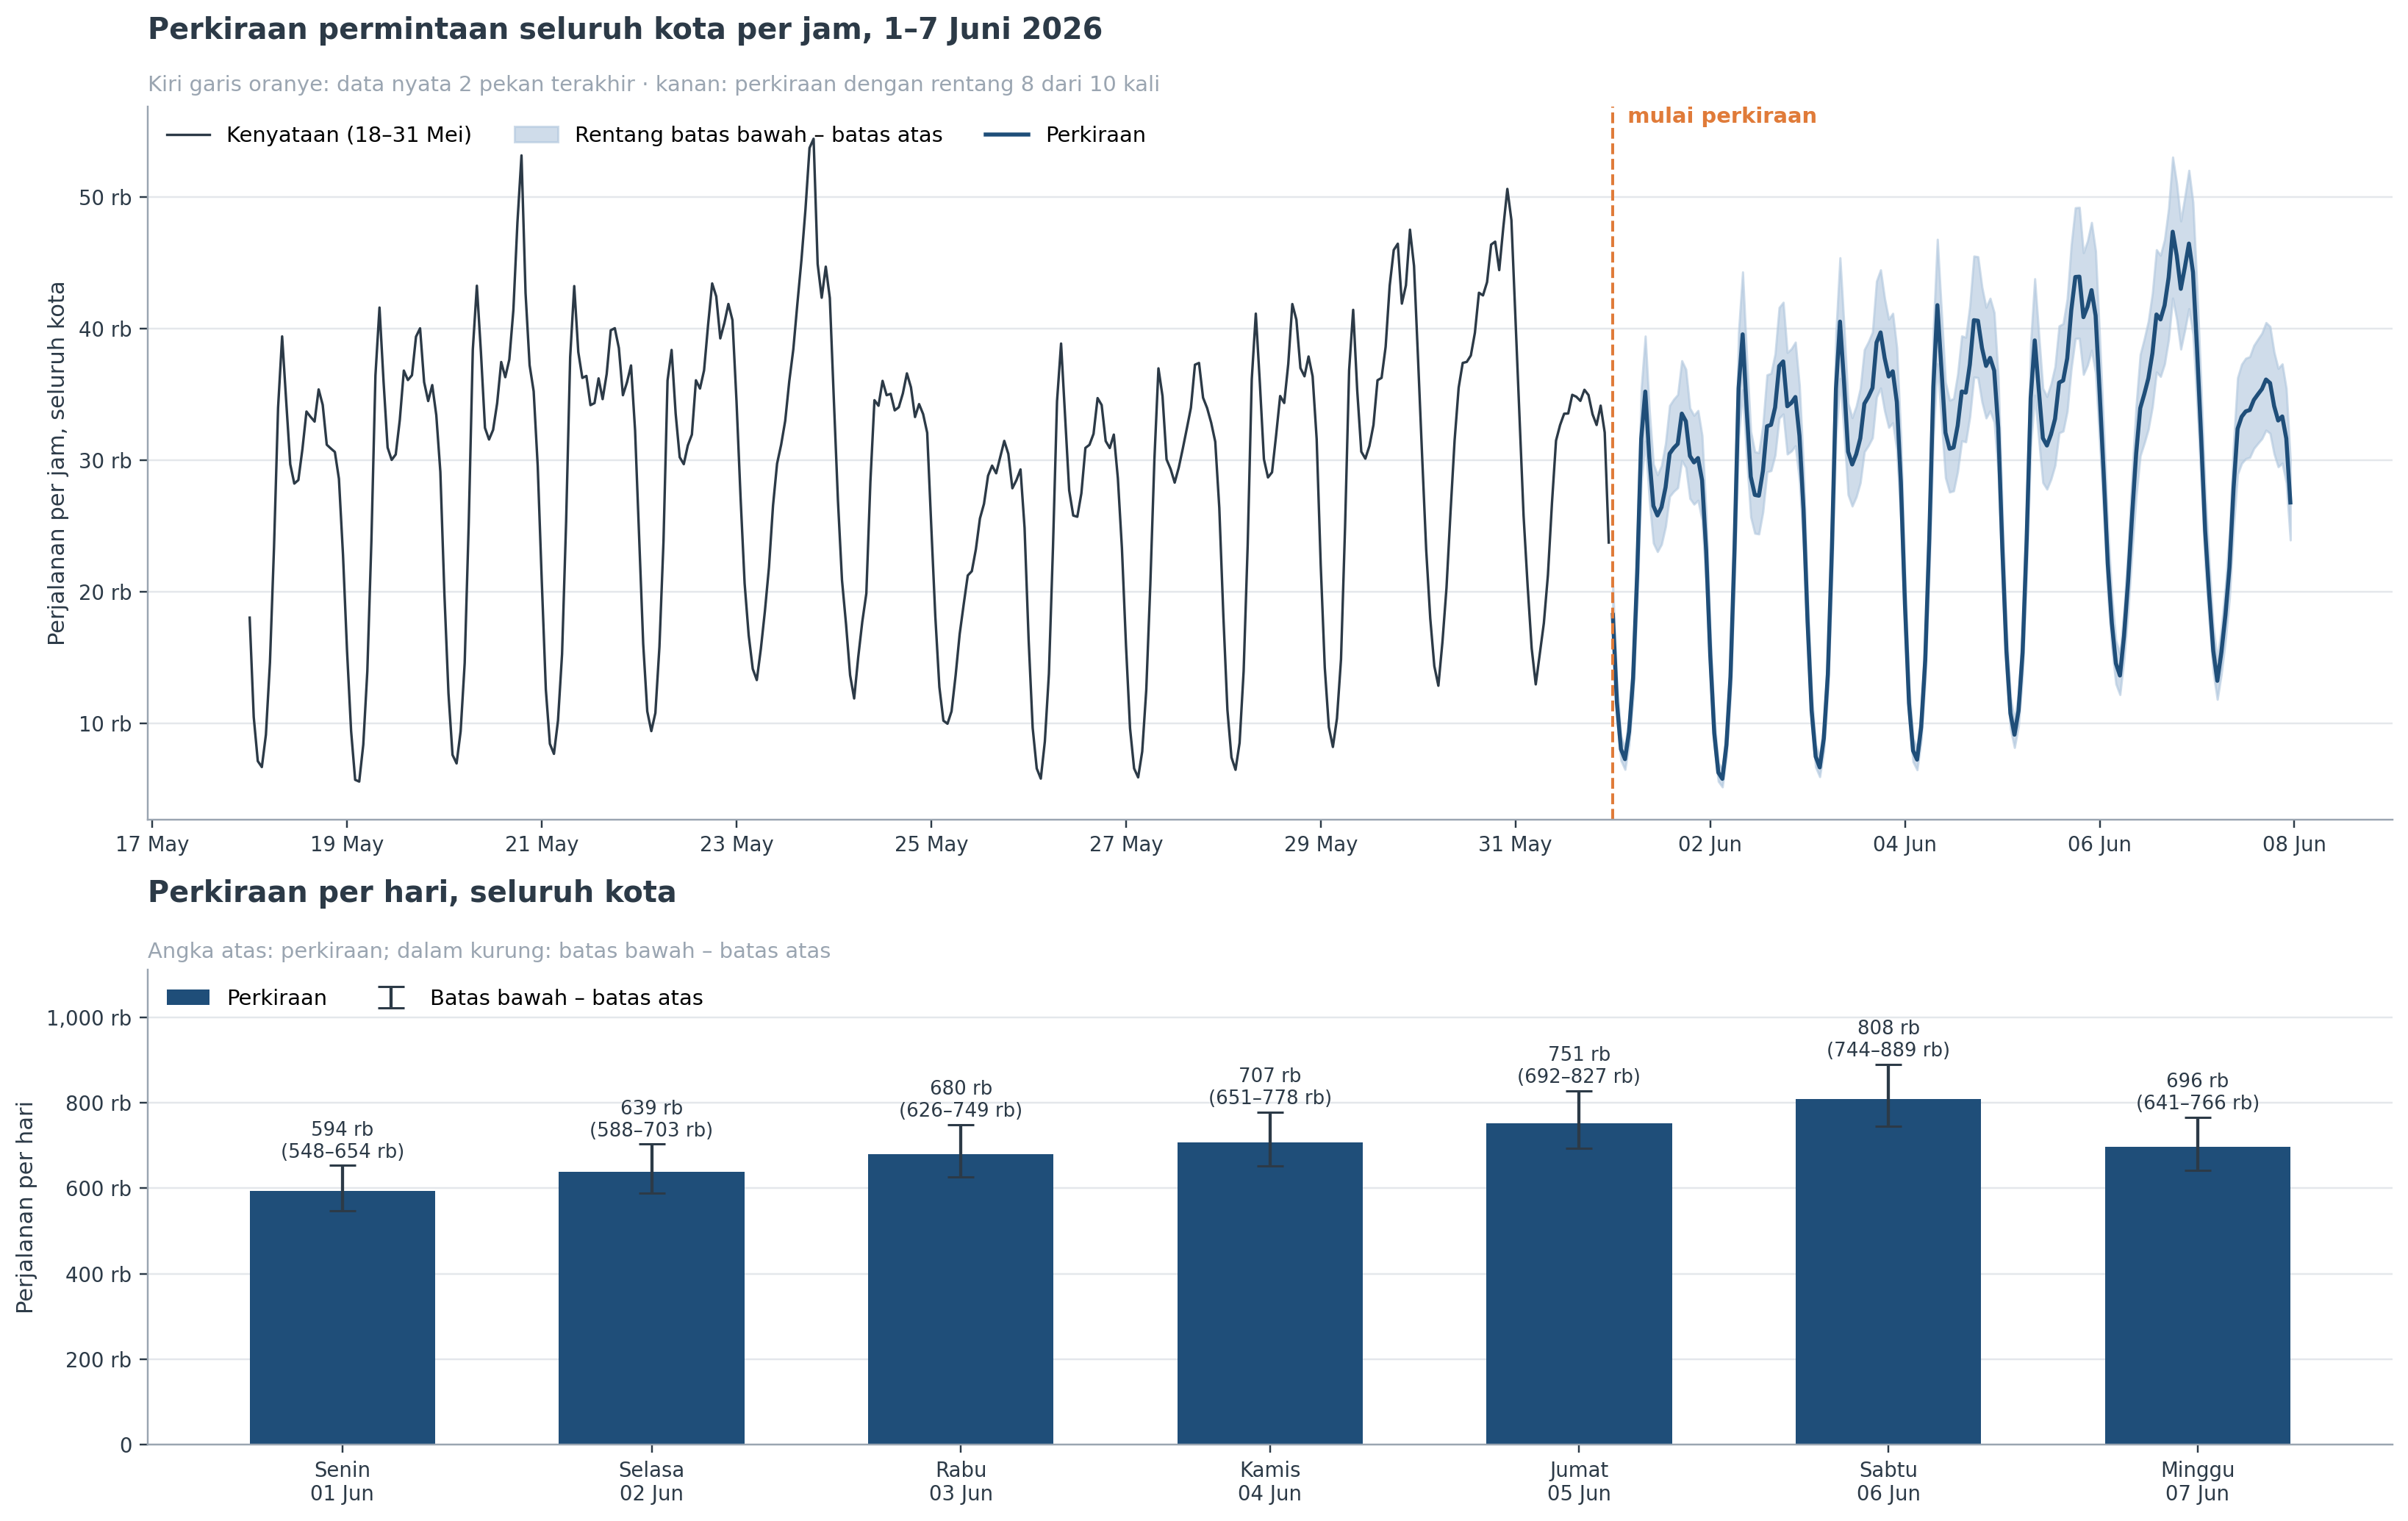

In [23]:
# ---------- Grafik: seluruh kota per jam ----------
kota_jam_depan = batas_agregat(agregat(gab_depan, ["jam"]), Q_AGR_AKHIR["Kota per jam"])
sejarah = agregat(gab_uji[gab_uji["jam"] >= pd.Timestamp(PERKIRAAN_MULAI) - pd.Timedelta(days=14)], ["jam"])

fig, axes = plt.subplots(2, 1, figsize=(15, 9.5), gridspec_kw={"height_ratios": [1.5, 1]})
ax = axes[0]
ax.plot(sejarah.index, sejarah["demand"], color=C["text"], linewidth=1.1, label="Kenyataan (18–31 Mei)")
ax.fill_between(kota_jam_depan.index, kota_jam_depan["batas_bawah"], kota_jam_depan["batas_atas"],
                color=C["band"], alpha=0.6, label="Rentang batas bawah – batas atas")
ax.plot(kota_jam_depan.index, kota_jam_depan["perkiraan"], color=C["primary"], linewidth=1.8, label="Perkiraan")
ax.axvline(pd.Timestamp(PERKIRAAN_MULAI), color=C["secondary"], linestyle="--", linewidth=1.3)
ax.text(pd.Timestamp(PERKIRAAN_MULAI), ax.get_ylim()[1], "  mulai perkiraan", color=C["secondary"],
        fontsize=9.5, va="top", fontweight="semibold")
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.yaxis.set_major_formatter(RIBU)
ax.set_ylabel("Perjalanan per jam, seluruh kota")
ax.legend(loc="upper left", ncol=3)
titled(ax, "Perkiraan permintaan seluruh kota per jam, 1–7 Juni 2026",
       "Kiri garis oranye: data nyata 2 pekan terakhir · kanan: perkiraan dengan rentang 8 dari 10 kali")
clean_axes(ax)

ax = axes[1]
xk = np.arange(len(kota_hari))
ax.bar(xk, kota_hari["perkiraan"], color=C["primary"], width=0.6, label="Perkiraan")
ax.errorbar(xk, kota_hari["perkiraan"],
            yerr=[kota_hari["perkiraan"] - kota_hari["batas_bawah"], kota_hari["batas_atas"] - kota_hari["perkiraan"]],
            fmt="none", ecolor=C["text"], elinewidth=1.4, capsize=6, label="Batas bawah – batas atas")
for i, r in kota_hari.iterrows():
    ax.text(i, r["batas_atas"] * 1.01, f"{r['perkiraan'] / 1000:,.0f} rb\n({r['batas_bawah'] / 1000:,.0f}–{r['batas_atas'] / 1000:,.0f} rb)",
            ha="center", va="bottom", fontsize=8.5, color=C["text"])
ax.set_xticks(xk)
ax.set_xticklabels([f"{h}\n{t:%d %b}" for h, t in zip(kota_hari["hari"], kota_hari["tanggal"])])
ax.set_ylim(0, kota_hari["batas_atas"].max() * 1.25)
ax.yaxis.set_major_formatter(RIBU)
ax.set_ylabel("Perjalanan per hari")
ax.legend(loc="upper left", ncol=2)
titled(ax, "Perkiraan per hari, seluruh kota", "Angka atas: perkiraan; dalam kurung: batas bawah – batas atas")
clean_axes(ax)
plt.tight_layout()
plt.show()

15 ZONA DENGAN PERKIRAAN TERBESAR, TOTAL 1–7 JUNI 2026


,nama_zona,batas_bawah,perkiraan,batas_atas
zona,,,,
138,LaGuardia Airport,"89,145","102,842","118,917"
132,JFK Airport,"70,533","81,370","94,089"
61,Crown Heights North,"53,366","61,566","71,190"
76,East New York,"48,379","55,812","64,536"
230,Times Sq/Theatre District,"47,124","54,365","62,863"
37,Bushwick South,"47,056","54,287","62,772"
161,Midtown Center,"45,975","53,039","61,329"
79,East Village,"45,723","52,748","60,993"
231,TriBeCa/Civic Center,"44,823","51,710","59,793"


Perkiraan per hari untuk 15 zona tersebut:


,nama_zona,Sen 01/06,Sel 02/06,Rab 03/06,Kam 04/06,Jum 05/06,Sab 06/06,Min 07/06
zona,,,,,,,,
138,LaGuardia Airport,"17,139","15,634","15,232","15,713","14,319","8,991","15,814"
132,JFK Airport,"13,178","10,920","10,361","10,955","11,486","10,784","13,684"
61,Crown Heights North,"7,192","7,474","7,769","8,483","9,644","11,230","9,775"
76,East New York,"6,905","7,273","7,783","8,281","9,189","8,774","7,607"
230,Times Sq/Theatre District,"6,705","8,005","8,947","8,857","7,469","7,525","6,858"
37,Bushwick South,"5,856","5,578","5,925","6,452","8,126","11,950","10,399"
161,Midtown Center,"6,991","9,008","10,084","10,073","6,929","5,933","4,021"
79,East Village,"4,946","5,427","6,155","6,522","8,260","12,106","9,334"
231,TriBeCa/Civic Center,"5,610","7,153","7,751","8,287","7,906","8,689","6,313"


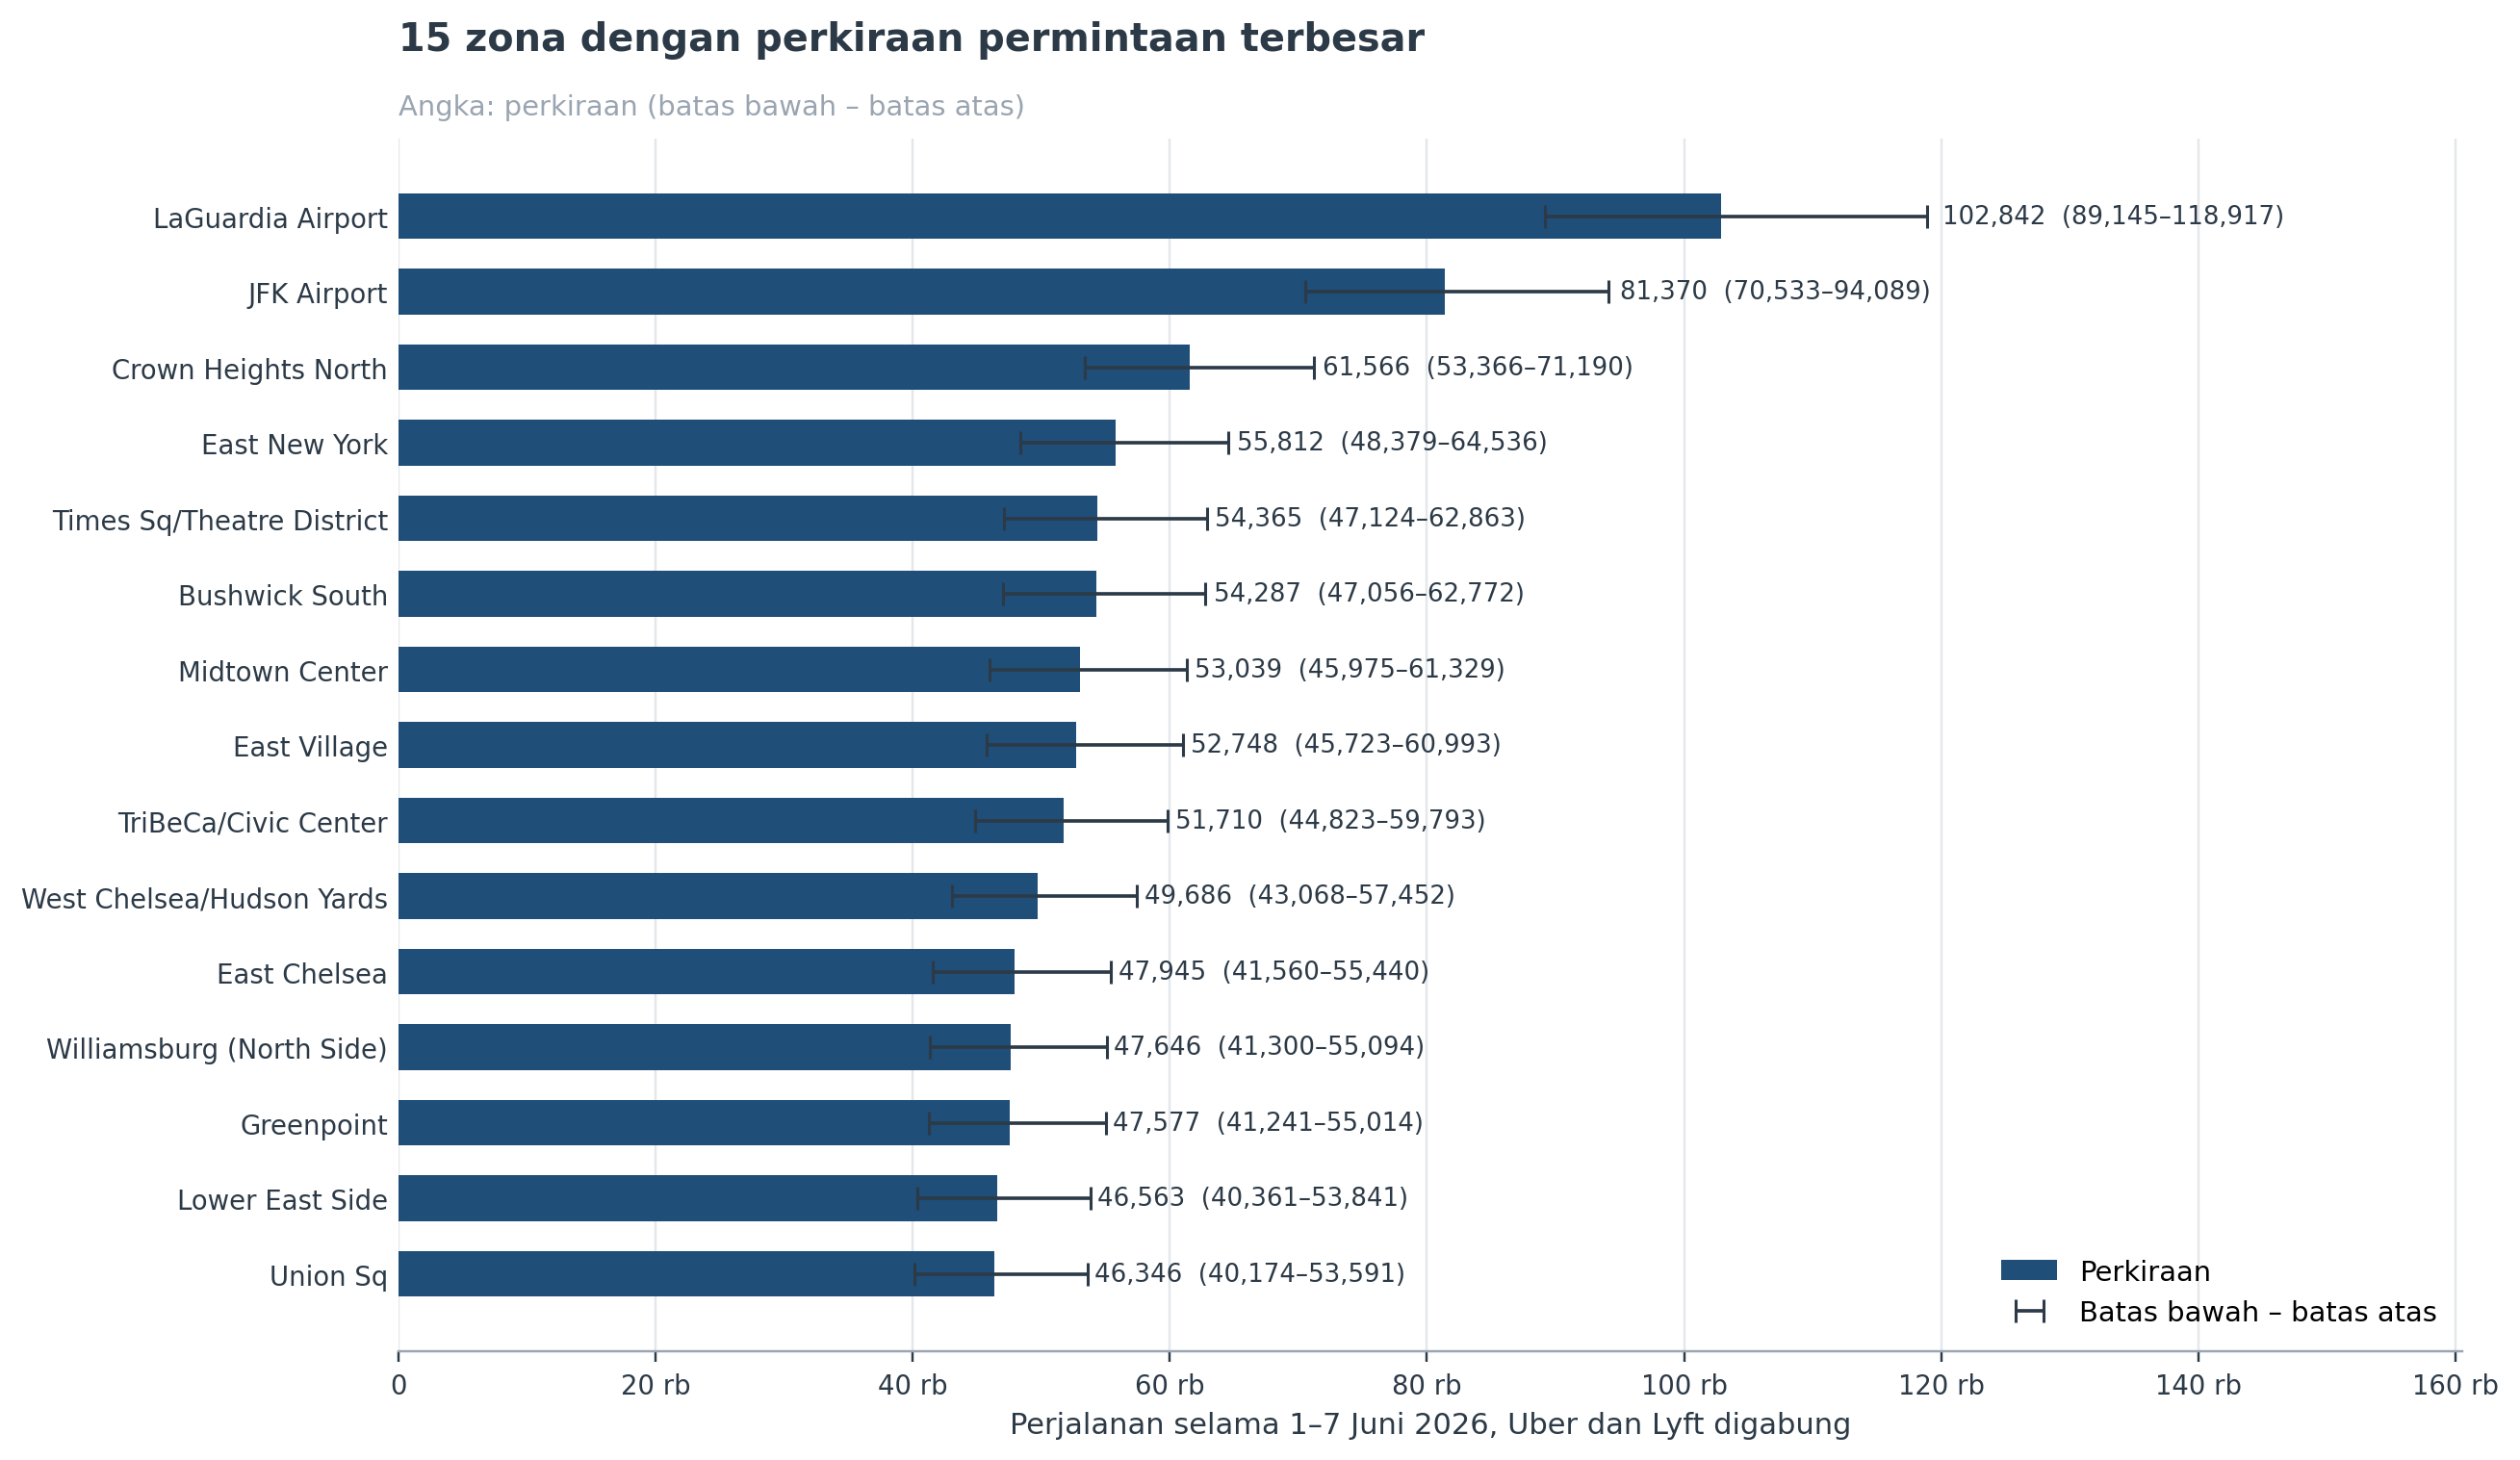

In [24]:
# ---------- Tabel dan grafik: 15 zona dengan perkiraan terbesar ----------
zona_hari = batas_agregat(agregat(gab_depan, ["zona", "tanggal"]), Q_AGR_AKHIR["Zona per hari"]).reset_index()
nama_zona = seri_info.drop_duplicates("zona").set_index("zona")["nama_zona"]
zona_pekan = zona_hari.groupby("zona")[["batas_bawah", "perkiraan", "batas_atas"]].sum() \
                      .sort_values("perkiraan", ascending=False)
atas15 = zona_pekan.head(15).copy()
atas15.insert(0, "nama_zona", atas15.index.map(nama_zona))

print("15 ZONA DENGAN PERKIRAAN TERBESAR, TOTAL 1–7 JUNI 2026")
display(atas15.style.format({"batas_bawah": "{:,.0f}", "perkiraan": "{:,.0f}", "batas_atas": "{:,.0f}"}))

rinci = zona_hari[zona_hari["zona"].isin(atas15.index)].pivot(index="zona", columns="tanggal", values="perkiraan") \
                  .loc[atas15.index]
rinci.columns = [f"{NAMA_HARI[t.dayofweek][:3]} {t:%d/%m}" for t in rinci.columns]
rinci.insert(0, "nama_zona", rinci.index.map(nama_zona))
print("Perkiraan per hari untuk 15 zona tersebut:")
display(rinci.style.format({c: "{:,.0f}" for c in rinci.columns if c != "nama_zona"}))

d = atas15.iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(d))
ax.barh(y, d["perkiraan"], color=C["primary"], height=0.6, label="Perkiraan")
ax.errorbar(d["perkiraan"], y, xerr=[d["perkiraan"] - d["batas_bawah"], d["batas_atas"] - d["perkiraan"]],
            fmt="none", ecolor=C["text"], elinewidth=1.2, capsize=4, label="Batas bawah – batas atas")
for i, (p, lo, hi) in enumerate(zip(d["perkiraan"], d["batas_bawah"], d["batas_atas"])):
    ax.text(hi * 1.01, i, f"{p:,.0f}  ({lo:,.0f}–{hi:,.0f})", va="center", fontsize=8.5, color=C["text"])
ax.set_yticks(y)
ax.set_yticklabels(d["nama_zona"])
ax.set_xlim(0, d["batas_atas"].max() * 1.35)
ax.xaxis.set_major_formatter(RIBU)
ax.set_xlabel("Perjalanan selama 1–7 Juni 2026, Uber dan Lyft digabung")
ax.legend(loc="lower right")
titled(ax, "15 zona dengan perkiraan permintaan terbesar", "Angka: perkiraan (batas bawah – batas atas)")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

In [25]:
# ---------- Tabel lengkap per seri per jam ----------
tabel_seri = gab_depan.merge(seri_info.assign(provider=seri_info["provider"].astype(str))[["provider", "zona", "nama_zona", "borough"]],
                             on=["provider", "zona"], how="left")
tabel_seri["cara"] = np.where(tabel_seri["kelompok_interval"] == "Di luar cakupan", "Rata-rata 4 pekan", "Model")
tabel_seri = tabel_seri[["jam", "zona", "nama_zona", "borough", "provider", "cara",
                         "batas_bawah", "perkiraan", "batas_atas"]].sort_values(["jam", "perkiraan"], ascending=[True, False])

print(f"Tabel perkiraan per seri per jam: {len(tabel_seri):,} baris "
      f"({tabel_seri[['zona', 'provider']].drop_duplicates().shape[0]} seri × {tabel_seri['jam'].nunique()} jam)")
print("Contoh: 10 seri terbesar pada Senin 1 Juni 2026 jam 18:00")
tabel_seri[tabel_seri["jam"] == pd.Timestamp("2026-06-01 18:00")].head(10) \
    .style.format({"batas_bawah": "{:,.1f}", "perkiraan": "{:,.1f}", "batas_atas": "{:,.1f}"}).hide(axis="index")

Tabel perkiraan per seri per jam: 88,032 baris (524 seri × 168 jam)
Contoh: 10 seri terbesar pada Senin 1 Juni 2026 jam 18:00


jam,zona,nama_zona,borough,provider,cara,batas_bawah,perkiraan,batas_atas
2026-06-01 18:00:00,138,LaGuardia Airport,Queens,Uber,Model,655.5,717.1,789.9
2026-06-01 18:00:00,132,JFK Airport,Queens,Uber,Model,453.9,505.7,566.9
2026-06-01 18:00:00,161,Midtown Center,Manhattan,Uber,Model,381.6,429.3,485.7
2026-06-01 18:00:00,138,LaGuardia Airport,Queens,Lyft,Model,296.9,339.3,389.4
2026-06-01 18:00:00,246,West Chelsea/Hudson Yards,Manhattan,Uber,Model,288.2,330.0,379.5
2026-06-01 18:00:00,234,Union Sq,Manhattan,Uber,Model,260.1,299.9,347.1
2026-06-01 18:00:00,230,Times Sq/Theatre District,Manhattan,Uber,Model,260.1,299.9,347.1
2026-06-01 18:00:00,61,Crown Heights North,Brooklyn,Uber,Model,250.0,289.1,335.5
2026-06-01 18:00:00,231,TriBeCa/Civic Center,Manhattan,Uber,Model,235.8,273.9,319.0
2026-06-01 18:00:00,68,East Chelsea,Manhattan,Uber,Model,232.8,270.6,315.4


> **Cara membaca Step 10**

**Yang diperkirakan adalah jumlah perjalanan**, untuk setiap zona × provider × jam selama 1–7 Juni 2026 — 524 seri × 168 jam. Grafik menjumlahkannya menjadi seluruh kota agar dapat dilihat dalam satu gambar; rincian per zona dan per seri ada di tabel.

**Tabel seluruh kota per hari** — untuk setiap tanggal: batas bawah, perkiraan, dan batas atas jumlah perjalanan seluruh kota. Perkiraan adalah angka untuk perencanaan. Batas bawah dan atas adalah skenario sepi dan ramai: 8 dari 10 hari, kenyataan diperkirakan berada di antaranya.

**Grafik per jam** — kiri garis oranye adalah data nyata dua pekan terakhir, kanan adalah perkiraan. Garis biru adalah perkiraan, area biru muda adalah rentangnya.

**Grafik per hari** — tinggi batang adalah perkiraan, garis tegak adalah rentang. Angka di atas batang: perkiraan, dan dalam kurung rentangnya.

**15 zona terbesar** — perkiraan total 1–7 Juni per zona, Uber dan Lyft digabung, lalu dirinci per hari.

**Tabel per seri per jam** — perkiraan paling rinci. Kolom `cara` menunjukkan apakah angkanya dari model atau dari rata-rata 4 pekan untuk seri di luar cakupan.

> **Hasil Step 10**

*Diisi setelah dijalankan: total perkiraan 7 hari dan rentangnya, hari teramai, dan zona dengan perkiraan terbesar.*

---

# STEP 11 — Menyimpan Hasil

In [26]:
# Model akhir
for g, mdl in STATE_AKHIR.get("model", {}).items():
    mdl.save_model(str(FOLDER_MODEL / f"model_akhir_{'semua' if g is None else g}.txt"))
if STATE_AKHIR["jenis"] == "linear":
    np.save(FOLDER_MODEL / "model_akhir_linear.npy", STATE_AKHIR["koef"])

# Perkiraan
tabel_seri.to_csv(FOLDER_MODEL / "perkiraan_seri_per_jam.csv", index=False)
tabel_kota.to_csv(FOLDER_MODEL / "perkiraan_kota_per_hari.csv", index=False)
zona_hari.assign(nama_zona=zona_hari["zona"].map(nama_zona)) \
         .to_csv(FOLDER_MODEL / "perkiraan_zona_per_hari.csv", index=False)
kota_jam_depan.reset_index().to_csv(FOLDER_MODEL / "perkiraan_kota_per_jam.csv", index=False)

# Penilaian
hasil_val.to_csv(FOLDER_MODEL / "penilaian_validasi_kandidat.csv")
hasil_uji.to_csv(FOLDER_MODEL / "penilaian_uji.csv")
per_kelompok.to_csv(FOLDER_MODEL / "penilaian_uji_per_kelompok.csv")
pd.DataFrame(cek).T.to_csv(FOLDER_MODEL / "cakupan_batas_uji.csv")
banding.to_csv(FOLDER_MODEL / "cakupan_kalibrasi_apr_mei.csv")
tabel_acf.to_csv(FOLDER_MODEL / "acf_lag_kunci.csv")
tabel_sisa.to_csv(FOLDER_MODEL / "acf_sisa_kesalahan.csv")

for f in sorted(FOLDER_MODEL.glob("*.*")):
    print(f"{f.name:40} {f.stat().st_size / 1e6:8.2f} MB")

acf_lag_kunci.csv                            0.00 MB
acf_sisa_kesalahan.csv                       0.00 MB
cakupan_batas_uji.csv                        0.00 MB
cakupan_kalibrasi_apr_mei.csv                0.00 MB
fitur.parquet                              215.95 MB
model_akhir_semua.txt                        2.70 MB
penilaian_uji.csv                            0.00 MB
penilaian_uji_per_kelompok.csv               0.00 MB
penilaian_validasi_kandidat.csv              0.00 MB
perkiraan_kota_per_hari.csv                  0.00 MB
perkiraan_kota_per_jam.csv                   0.01 MB
perkiraan_seri_per_jam.csv                   9.96 MB
perkiraan_zona_per_hari.csv                  0.16 MB
seri_info.parquet                            0.02 MB


---

# STEP 12 — Ringkasan

*Diisi setelah seluruh step dijalankan.*

| Pertanyaan | Jawaban |
|---|---|
| Lag mana yang paling berguna menurut ACF dan PACF? | |
| Model mana yang terpilih, dan mengapa? | |
| Apakah memisah model per kelompok atau per provider membantu? | |
| Apakah model lebih akurat dari pembanding terbaik pada periode uji, di setiap kelompok seri? | |
| Apakah sisa kesalahan masih berpola mingguan? | |
| Apakah batas bawah dan atas mengapit sekitar 80% kenyataan, sebelum dan sesudah kalibrasi ulang? | |
| Berapa perkiraan total 1–7 Juni 2026, dan rentangnya? | |

**Batas kesimpulan**

| Batas | Konsekuensi |
|---|---|
| Hanya perjalanan yang terlaksana yang tercatat | Perkiraan adalah permintaan terlayani, bukan permintaan sebenarnya |
| Satu periode uji, Januari–Mei 2026 | Kinerja pada musim sepi Juli–Agustus belum teruji |
| Fitur memakai data paling baru 168 jam sebelumnya | Perkiraan sah hingga 7 hari ke depan |
| Tidak ada data cuaca dan acara | Lonjakan akibat cuaca atau acara besar tidak dapat diperkirakan |
| Rentang dikalibrasi dari Oktober–Desember 2025 | Bila pola penyimpangan berubah, cakupan dapat bergeser dari 80% |

---

# CATATAN EKSEKUSI

**Urutan:** jalankan dari atas ke bawah. Step 2–4 memakai DuckDB di memori; bila kernel di-restart setelah Step 4, cukup jalankan setup lalu mulai dari Step 5 — fitur sudah tersimpan di `fitur.parquet`.

**Waktu:** Step 7 melatih lima kandidat dan paling lama, umumnya 10–30 menit. Step 8 dan Step 10 masing-masing melatih ulang model terpilih satu kali.

**Memori:** data dibaca sebagai angka 4 byte, sekitar 1 GB. Bila memori tidak cukup, ubah `LATIH_MULAI` menjadi `"2025-01-01 00:00:00"` lalu jalankan ulang dari Step 4.